## 1. Imports and load data

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

import random

from scipy import stats
from scipy.stats import pearsonr
from wordfreq import zipf_frequency

from flow_tree_utils import (
    steiger_z_test,
    get_matched_random_walk,
    generate_flow_tree_from_trajs,
    plot_flow_tree,
)

### Load wikispeedia data, etc

In [2]:
### Load articles and categories
data_path = "data/wikispeedia_paths-and-graph"

# load article names
article_names = []
with open(f"{data_path}/articles.tsv") as f:
    for line in f:
        line = line.strip()
        if len(line) == 0 or line[0] == "#":
            continue

        article_names.append(line)
print(f"{len(article_names)} nodes/articles loaded.")

# load links
column_names = ["linkSource", "linkTarget"]
edges_df = pd.read_csv(
    f"{data_path}/links.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(13)],
)
print(f"{len(edges_df)} edges/hyperlinks loaded.")

wikiG = nx.DiGraph()
wikiG.add_edges_from(zip(edges_df.linkSource, edges_df.linkTarget))
print(wikiG)

4604 nodes/articles loaded.
119881 edges/hyperlinks loaded.
DiGraph with 4592 nodes and 119881 edges


In [ ]:
### Load trajectories
def get_nth_article(article_string, n):
    article_list = article_string.split(";")
    return article_list[n]


def get_path_len(x):
    return len(x.split(";"))


# load successful trajectories
column_names = ["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"]
finished_trajs_df = pd.read_csv(
    f"{data_path}/paths_finished.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(16)],
)
finished_trajs_df["StartAt"] = finished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, 0)
)
finished_trajs_df["EndAt"] = finished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, -1)
)
finished_trajs_df["finished"] = True

# load unsuccessful trajectories
column_names = [
    "hashedIpAddress",
    "timestamp",
    "durationInSec",
    "path",
    "target",
    "type",
]
unfinished_trajs_df = pd.read_csv(
    f"{data_path}/paths_unfinished.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(17)],
)
unfinished_trajs_df["StartAt"] = unfinished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, 0)
)
unfinished_trajs_df["EndAt"] = unfinished_trajs_df["target"]
unfinished_trajs_df["finished"] = False

trajs_df = pd.concat([finished_trajs_df, unfinished_trajs_df])
trajs_df.reset_index()
trajs_df["traj_len"] = trajs_df["path"].apply(get_path_len)
# trajs_df["levels_traj"] = trajs_df["path"].apply(get_levels_traj)
# trajs_df["level_hops"] = trajs_df["path"].apply(get_level_hops)

# don't want multiple attempts for each person
print(f"{trajs_df.shape[0]} trajectories before dupes removed")
trajs_df = trajs_df.drop_duplicates(subset=["hashedIpAddress", "StartAt", "target"])

print(f"Final data has {trajs_df.shape[0]} trajectories")
print(
    f"\twith {len(trajs_df.StartAt.unique())} unique starts and {len(trajs_df.EndAt.unique())} unique ends"
)
print(f"\tand {len(trajs_df.hashedIpAddress.unique())} unique players")


def process_path(path):
    # Longest backclick sequence is 22 <;<;<;<;<;<;<;<;<;<;<;<;<;<;< + more
    # print(path)
    assert ";<" * 23 not in path

    for i in range(21, 0, -1):
        backtrack_seq = "<" + ";<" * i
        if backtrack_seq in path:
            path = path.replace(backtrack_seq, f"<{i + 1}")

    split_path = path.split(";")
    real_nodes = []
    for i, node in enumerate(split_path):
        if "<" in node:
            bktrk = 1 if node == "<" else int(node[1:])
            node = real_nodes[i - bktrk - 1]
        real_nodes.append(node)

    return real_nodes


trajs_df["traj"] = trajs_df["path"].apply(process_path)
trajs_df["StartEnd"] = trajs_df["StartAt"] + "__" + trajs_df["EndAt"]

trajs_df["accuracy"] = trajs_df.groupby("StartEnd")["finished"].transform("mean")
trajs_df["avg_rating"] = trajs_df.groupby("StartEnd")["rating"].transform("mean")

trajs_df[["StartEnd", "traj", "accuracy", "avg_rating"]].head()

76193 trajectories before dupes removed
Final data has 70770 trajectories
	with 4168 unique starts and 3997 unique ends
	and 20868 unique players


,StartEnd,traj,accuracy,avg_rating
0,14th_century__African_slave_trade,"[14th_century, 15th_century, 16th_century, Pac...",0.428571,3.0
1,14th_century__African_slave_trade,"[14th_century, Europe, Africa, Atlantic_slave_...",0.428571,3.0
2,14th_century__African_slave_trade,"[14th_century, Niger, Nigeria, British_Empire,...",0.428571,3.0
3,14th_century__Greece,"[14th_century, Renaissance, Ancient_Greece, Gr...",1.000000,NaN
4,14th_century__John_F._Kennedy,"[14th_century, Italy, Roman_Catholic_Church, H...",1.000000,3.0


## 2. Helper fns
to make below less gross

In [ ]:
node_counts = {}
for trajectory in trajs_df.traj:
    for node in trajectory:
        node_counts[node] = node_counts.get(node, 0) + 1

stop_words = set(["a", "an", "the", "and", "for", "of"])

node_indegrees = {}
node_outdegrees = {}
node_zipf_frequencies = {}
for node in node_counts:
    if node in wikiG:
        node_indegrees[node] = wikiG.in_degree(node)
        node_outdegrees[node] = wikiG.out_degree(node)
        node_zipf_frequencies[node] = np.mean(
            [
                zipf_frequency(word, "en")
                for word in node.split("_")
                if word not in stop_words
            ]
        )


# find most common nodes
def find_k_most_x_nodes(
    node_value_dict, k=100, restrict_to=None, actually_most=True, verbose_str=None
):
    if restrict_to is None:
        restrict_to = node_value_dict.keys()
    most_x_nodes = sorted(
        [x for x in restrict_to],
        key=lambda x: node_value_dict[x],
        reverse=actually_most,
    )[:k]

    if verbose_str:
        print(
            f"{'Most' if actually_most else 'Least'} {verbose_str} node is {most_x_nodes[0]} with {node_value_dict[most_x_nodes[0]]}; "
            f"{k}th {'most' if actually_most else 'least'} is {most_x_nodes[-1]} with {node_value_dict[most_x_nodes[-1]]}"
        )
    return most_x_nodes

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

# pip install "tokenizers<0.22" --force-reinstall
model_name = "bert-base-uncased"
tok = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)


def embed(text):
    tokens = tok(text.replace("_", " "), return_tensors="pt", truncation=True)
    out = model(**tokens)
    # mean pooling
    emb = out.last_hidden_state.mean(dim=1)
    return emb.detach()


def cosine(a, b):
    return F.cosine_similarity(a, b).item()


def get_topic_distance(topic1, topic2):
    return cosine(embed(topic1), embed(topic2))


get_topic_distance("the_dog", "the_cat")

0.9181366562843323

In [ ]:
embeddings_dict = {node: embed(node) for node in node_counts}

In [35]:
degree_cache = {}
zipf_cache = {}
cosine_cache = {}

In [ ]:
def get_weighted_matched_random_walk(
    G, start_node, walk_length, weights, degree_cache=degree_cache
):
    trajectory = [start_node]
    current_node = start_node

    for _ in range(walk_length):
        neighbors = sorted(list(G.neighbors(current_node)))

        if len(neighbors) == 0:
            if len(trajectory) < 2:
                current_node = trajectory[-1]
            else:
                current_node = trajectory[-2]
        elif len(neighbors) == 1:
            current_node = neighbors[0]
        else:
            # if current_node in degree_cache:
            #     # print("using cache")
            #     these_weights = degree_cache[current_node]
            # else:
            # print("adding to cache", current_node)
            these_weights = [weights[n] for n in neighbors]
            # degree_cache[current_node] = these_weights
            try:
                current_node = random.choices(neighbors, these_weights, k=1)[0]
            except:
                print(these_weights)
        trajectory.append(current_node)

    return trajectory


def get_targeted_matched_random_walk(G, start_node, target, walk_length):
    trajectory = [start_node]
    current_node = start_node

    # print(start_node, target)
    # print(walk_length)

    # TODO: this should be based on similariyt to target youa re so stupid
    for _ in range(walk_length):
        neighbors = sorted(list(G.neighbors(current_node)))
        if len(neighbors) == 0:
            if len(trajectory) < 2:
                current_node = trajectory[-1]
            else:
                current_node = trajectory[-2]
        else:
            if current_node in cosine_cache:
                # print("using cache")
                weights = cosine_cache[current_node]
            else:
                weights = []
                for n in neighbors:
                    w1 = embeddings_dict.get(n, embed(n))
                    if n not in embeddings_dict:
                        embeddings_dict[n] = w1

                    w2 = embeddings_dict.get(current_node, embed(current_node))
                    if current_node not in embeddings_dict:
                        embeddings_dict[current_node] = w2
                    dist = cosine(w1, w2)
                    weights.append(dist)
                cosine_cache[current_node] = weights
                print("added to cache", current_node)

            current_node = random.choices(neighbors, weights, k=1)[0]
        trajectory.append(current_node)
    return trajectory

In [10]:
degree_centrality = nx.degree_centrality(wikiG)
print("Degree Centrality:", degree_centrality)

word_frequency_centrality = {}
for node in wikiG.nodes():
    word_frequency_centrality[node] = np.mean(
        [zipf_frequency(word, "en") for word in node.split("_")]
    )
print("Word Frequency Centrality:", word_frequency_centrality)

Degree Centrality: {'%C3%81ed%C3%A1n_mac_Gabr%C3%A1in': 0.0021781746896101066, 'Columba': 0.005009801786103245, 'D%C3%A1l_Riata': 0.006970159006752342, 'Great_Britain': 0.0468307558266173, 'Ireland': 0.08494881289479417, 'Isle_of_Man': 0.021128294489218036, 'Monarchy': 0.04356349379220214, 'Orkney': 0.013286865606621652, 'Picts': 0.00958396863428447, 'Scotland': 0.0980178610324548, 'Wales': 0.0490089305162274, '%C3%85land': 0.004138531910259203, '20th_century': 0.08690917011544326, 'Baltic_Sea': 0.024177739054672187, 'Crimean_War': 0.012197778261816599, 'Currency': 0.06817686778479634, 'Euro': 0.03201916793726857, 'European_Union': 0.08298845567414508, 'Finland': 0.04966238292311043, 'League_of_Nations': 0.029840993247658463, 'List_of_countries_by_system_of_government': 0.09867131343933784, 'Nationality': 0.00936615116532346, 'Parliamentary_system': 0.02940535830973644, 'Police': 0.021128294489218036, 'Russia': 0.13613591810063166, 'Stockholm': 0.013722500544543673, 'Sweden': 0.0847309

In [ ]:
def make_traj_dict(node_list, trajs_df, min_path_length=5):
    traj_dict = {x: [] for x in node_list}
    for traj in trajs_df.traj:
        for i in range(len(traj) - min_path_length - 1):  # want min path length 5?
            if traj[i] in node_list:
                traj_dict[traj[i]].append(traj[i : i + min_path_length])
    return traj_dict


def make_rev_traj_dict(node_list, trajs_df, min_path_length=5):
    rev_traj_dict = {x: [] for x in node_list}
    for traj in trajs_df.traj:
        for i in range(min_path_length, len(traj)):  # want min path length 7?
            if traj[i] in node_list:
                rev_traj = [x for x in reversed(traj[i - min_path_length : i])]
                rev_traj_dict[traj[i]].append(rev_traj)
    return rev_traj_dict


def sample_flow_trees_from_traj_dict(traj_dict, wikiG, k_fold=5, traj_per_tree=20):
    flow_tree_dict = {}
    for node in traj_dict:
        trees = []
        random_trees, weighted_random_trees, targeted_random_trees = [], [], []
        for _ in range(k_fold):
            sampled_trajs = traj_dict[node]
            if len(sampled_trajs) > traj_per_tree:
                sampled_indices = np.random.choice(
                    len(sampled_trajs), size=traj_per_tree, replace=False
                )
                sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
            # else:
            #     print(len(sampled_trajs))
            G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
            new_G = nx.relabel.convert_node_labels_to_integers(
                G, first_label=0, ordering="default"
            )
            trees.append(new_G)

            # using random data
            if sampled_trajs[0][0] in wikiG:
                # print("making random trajs")
                random_trajs = [
                    get_matched_random_walk(
                        wikiG, sampled_trajs[0][0], len(sampled_trajs[i])
                    )
                    for i in range(len(sampled_trajs))
                ]
                random_weighted_trajs = [
                    get_weighted_matched_random_walk(
                        wikiG,
                        sampled_trajs[0][0],
                        len(sampled_trajs[i]),
                        degree_centrality,
                        degree_cache={},
                    )
                    for i in range(len(sampled_trajs))
                ]
                # print("dc", len(degree_cache))

                random_semantic_trajs = [
                    get_weighted_matched_random_walk(
                        wikiG,
                        sampled_trajs[0][0],
                        len(sampled_trajs[i]),
                        word_frequency_centrality,
                        degree_cache={},
                    )
                    for i in range(len(sampled_trajs))
                ]

                # [get_targeted_matched_random_walk(
                #     wikiG, sampled_trajs[0][0], sampled_trajs[i][-1], len(sampled_trajs[i])
                # ) for i in range(len(sampled_trajs))]
                # print("cc", len(cosine_cache))
                # print("done")

                random_G = generate_flow_tree_from_trajs(random_trajs, END_NODE="1")
                new_G = nx.relabel.convert_node_labels_to_integers(
                    random_G, first_label=0, ordering="default"
                )
                if (0, 0) in new_G.edges:
                    new_G.remove_edge(0, 0)
                random_trees.append(new_G)

                weighted_random_G = generate_flow_tree_from_trajs(
                    random_weighted_trajs, END_NODE="1"
                )
                new_G = nx.relabel.convert_node_labels_to_integers(
                    weighted_random_G, first_label=0, ordering="default"
                )
                if (0, 0) in new_G.edges:
                    new_G.remove_edge(0, 0)
                weighted_random_trees.append(new_G)

                random_G = generate_flow_tree_from_trajs(
                    random_semantic_trajs, END_NODE="1"
                )
                new_G = nx.relabel.convert_node_labels_to_integers(
                    random_G, first_label=0, ordering="default"
                )
                if (0, 0) in new_G.edges:
                    new_G.remove_edge(0, 0)
                targeted_random_trees.append(new_G)

                # print("done making trees")
        flow_tree_dict[node] = {
            "human": trees,
            "random": random_trees,
            "weighted_random": weighted_random_trees,
            "targeted_random": targeted_random_trees,
        }
    return flow_tree_dict

In [ ]:
def plot_some_from_flow_tree_dict(flow_tree_dict, title_str=""):
    n_cols = 6
    fig, axes = plt.subplots(4, n_cols, figsize=(20, 8))
    for j, node in enumerate(flow_tree_dict):
        G = flow_tree_dict[node]["human"][0]
        ax = axes[0][j]
        plot_flow_tree(G, f"HUMAN init at {node}", ax, just_edges=True, no_title=False)

        random_G = flow_tree_dict[node]["random"][0]
        ax = axes[1][j]
        plot_flow_tree(
            random_G, f"RANDOM init at {node}", ax, just_edges=True, no_title=False
        )

        random_G = flow_tree_dict[node]["weighted_random"][0]
        ax = axes[2][j]
        plot_flow_tree(
            random_G,
            f"WEIGHTED RANDOM init at {node}",
            ax,
            just_edges=True,
            no_title=False,
        )

        random_G = flow_tree_dict[node]["targeted_random"][0]
        ax = axes[3][j]
        plot_flow_tree(
            random_G,
            f"TARGETED RANDOM init at {node}",
            ax,
            just_edges=True,
            no_title=False,
        )

        if j == n_cols - 1:
            break
    plt.suptitle(title_str)
    plt.tight_layout()
    plt.show()

In [ ]:
def make_flow_tree_dict_from_node_list(
    node_list,
    trajs_df,
    min_path_length=7,
    wikiG=wikiG,
    k_fold=5,
    traj_per_tree=20,
    plot_title_str=None,
):
    traj_dict = make_traj_dict(node_list, trajs_df, min_path_length=min_path_length)
    flow_tree_dict = sample_flow_trees_from_traj_dict(
        traj_dict, wikiG, k_fold=k_fold, traj_per_tree=traj_per_tree
    )

    if plot_title_str:
        plot_some_from_flow_tree_dict(flow_tree_dict, title_str=plot_title_str)

    return flow_tree_dict

In [ ]:
def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()

    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())

    depth = tree_depth(graph, root)

    # Diameter
    diameter = nx.diameter(graph)

    # backbone_path, max_weight, weights = get_heaviest_path(graph, root)
    # backbone_thickness = np.mean(weights) / max_weight

    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)

    # Branching Factor
    branching_factors = [
        len(list(graph.neighbors(node)))
        for node in graph.nodes()
        if graph.degree(node) != 1
    ]
    avg_branching_factor = np.mean(branching_factors)

    # Put all features in a list
    features = [
        num_nodes,
        num_leaves,
        depth,
        avg_branching_factor,
        # backbone_thickness,
        diameter,
    ]

    return features


def run_ttests_on_flow_tree_groups(
    group1_trees,
    group2_trees,
    normalise=False,
    group1_name="Group 1",
    group2_name="Group 2",
):
    results_df = pd.DataFrame(
        columns=[
            "group1_name",
            "group2_name",
            "group1_mean",
            "group2_mean",
            "group1_var",
            "group2_var",
            "group1_n",
            "group2_n",
            "statistic",
            "p_value",
            "metric",
            "notes",
        ]
    )

    feature_names = [
        "num_nodes",
        "num_leaves",
        "depth",
        "avg_branching_factor",
        "diameter",
    ]

    group1_features = np.array([extract_tree_features(G, 0) for G in group1_trees])
    group2_features = np.array([extract_tree_features(G, 0) for G in group2_trees])

    # Test each feature
    for i, feature_name in enumerate(feature_names):
        group1_feature = group1_features[:, i]
        group2_feature = group2_features[:, i]

        if normalise:
            # Normalize features to 0-1 range
            all_features = np.concatenate([group1_feature, group2_feature])
            feature_min = np.min(all_features)
            feature_max = np.max(all_features)

            # Avoid division by zero if min==max
            if feature_max > feature_min:
                group1_feature = (group1_feature - feature_min) / (
                    feature_max - feature_min
                )
                group2_feature = (group2_feature - feature_min) / (
                    feature_max - feature_min
                )

        # T-test
        t_stat, p_val = stats.ttest_ind(group1_feature, group2_feature)
        results_df.loc[len(results_df)] = {
            "group1_name": group1_name,
            "group2_name": group2_name,
            "group1_mean": np.mean(group1_feature),
            "group2_mean": np.mean(group2_feature),
            "group1_var": np.var(group1_feature),
            "group2_var": np.var(group2_feature),
            "group1_n": len(group1_feature),
            "group2_n": len(group2_feature),
            "statistic": t_stat,
            "p_value": p_val,
            "metric": feature_name,
            "notes": f"Comparing flow tree {feature_name} between {group1_name} and {group2_name}",
        }

    return results_df, group1_features, group2_features

## 3. Idk make Flow Trees?

In [ ]:
big_k = 500
small_k = 50
most_common_nodes = find_k_most_x_nodes(node_counts, k=big_k, verbose_str="common")
most_indegree_nodes = find_k_most_x_nodes(
    node_indegrees, k=small_k, restrict_to=most_common_nodes, verbose_str="indegree"
)
least_indegree_nodes = find_k_most_x_nodes(
    node_indegrees,
    k=small_k,
    restrict_to=most_common_nodes,
    actually_most=False,
    verbose_str="indegree",
)
most_outdegree_nodes = find_k_most_x_nodes(
    node_outdegrees, k=small_k, restrict_to=most_common_nodes, verbose_str="outdegree"
)
least_outdegree_nodes = find_k_most_x_nodes(
    node_outdegrees,
    k=small_k,
    restrict_to=most_common_nodes,
    actually_most=False,
    verbose_str="outdegree",
)

print()
print(
    "Most outdegree, most indegree overlap",
    len(set(most_indegree_nodes).intersection(set(most_outdegree_nodes))),
)
print(
    "Least outdegree, least indegree overlap",
    len(set(least_indegree_nodes).intersection(set(least_outdegree_nodes))),
)

Most common node is United_States with 12660; 500th most is Nintendo_Entertainment_System with 173
Most indegree node is United_States with 1551; 50th most is Brazil with 261
Least indegree node is Education_in_the_United_States with 3; 50th least is Penguin with 26
Most outdegree node is United_States with 294; 50th most is NATO with 96
Least outdegree node is Animation with 3; 50th least is Pyramid with 17

Most outdegree, most indegree overlap 20
Least outdegree, least indegree overlap 16


In [ ]:
len(degree_cache)

0

In [ ]:
len(cosine_cache)

565

In [ ]:
most_common_flow_tree_dict = make_flow_tree_dict_from_node_list(
    most_common_nodes,
    trajs_df,
    min_path_length=6,
    wikiG=wikiG,
    k_fold=5,
    traj_per_tree=15,
    plot_title_str=None,
)

making random trajs
dc 1969
cc 0
done
done making trees
making random trajs
dc 1969
cc 0
done
done making trees
making random trajs
dc 1969
cc 0
done
done making trees
making random trajs
dc 1969
cc 0
done
done making trees
making random trajs
dc 1970
cc 0
done
done making trees
making random trajs
dc 1973
cc 0
done
done making trees
making random trajs
dc 1973
cc 0
done
done making trees
making random trajs
dc 1973
cc 0
done
done making trees
making random trajs
dc 1973
cc 0
done
done making trees
making random trajs
dc 1974
cc 0
done
done making trees
making random trajs
dc 1975
cc 0
done
done making trees
making random trajs
dc 1976
cc 0
done
done making trees
making random trajs
dc 1976
cc 0
done
done making trees
making random trajs
dc 1976
cc 0
done
done making trees
making random trajs
dc 1977
cc 0
done
done making trees
making random trajs
dc 1977
cc 0
done
done making trees
making random trajs
dc 1977
cc 0
done
done making trees
making random trajs
dc 1977
cc 0
done
done makin

Most indegree:


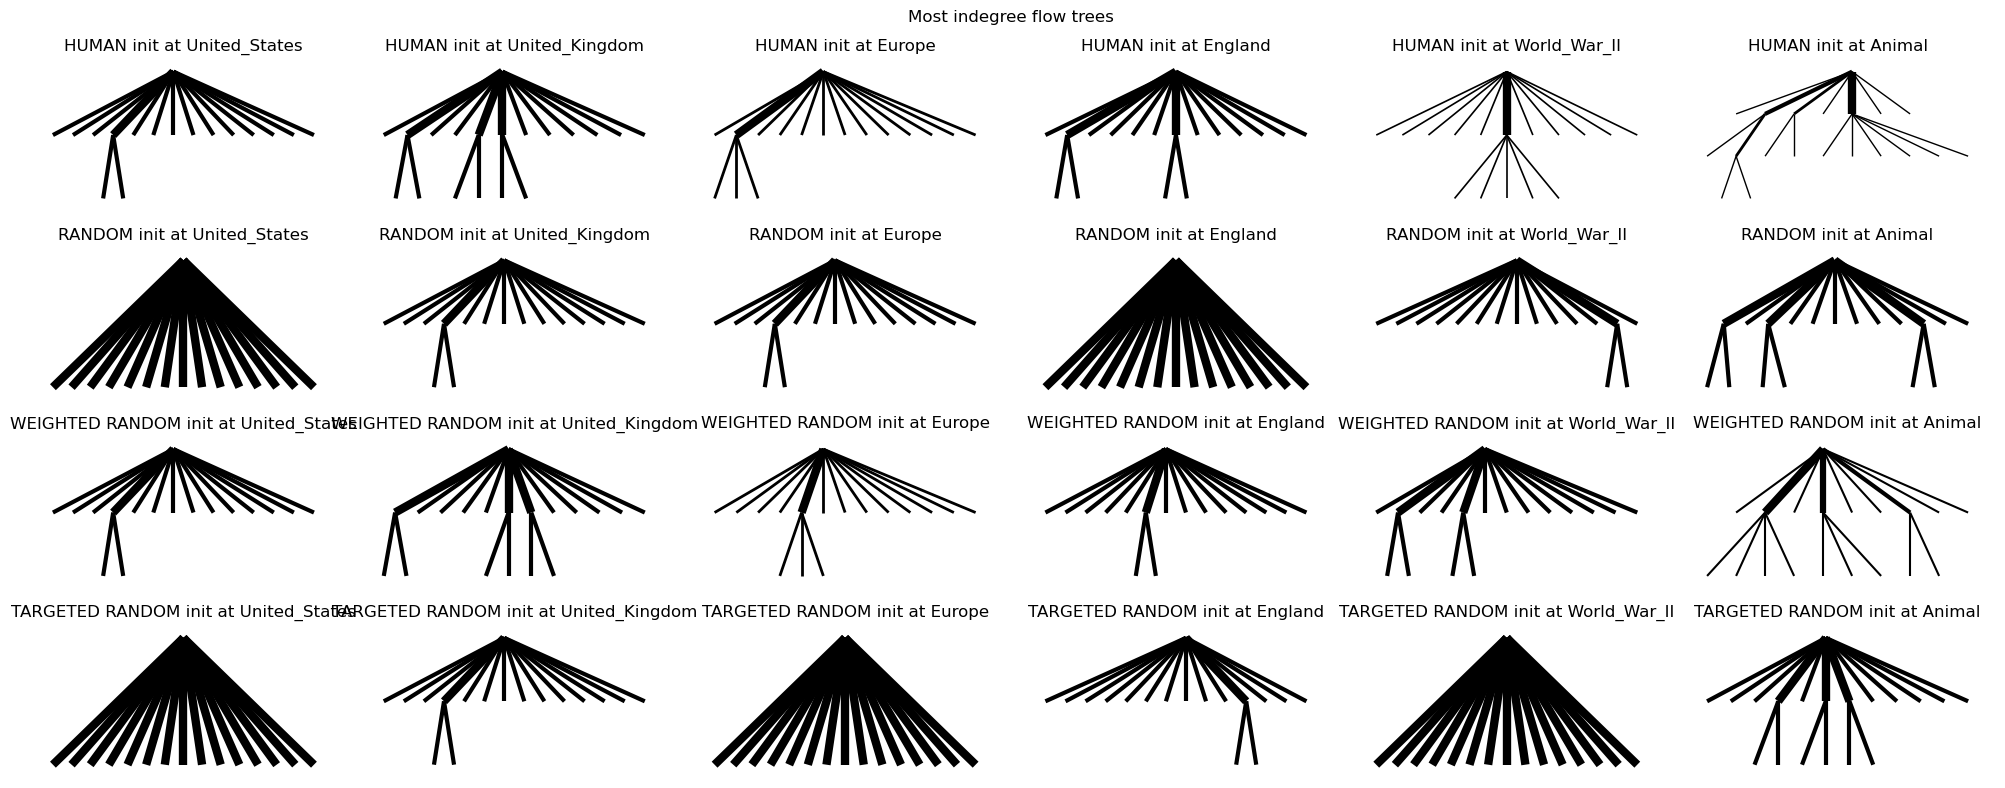

Least indegree:


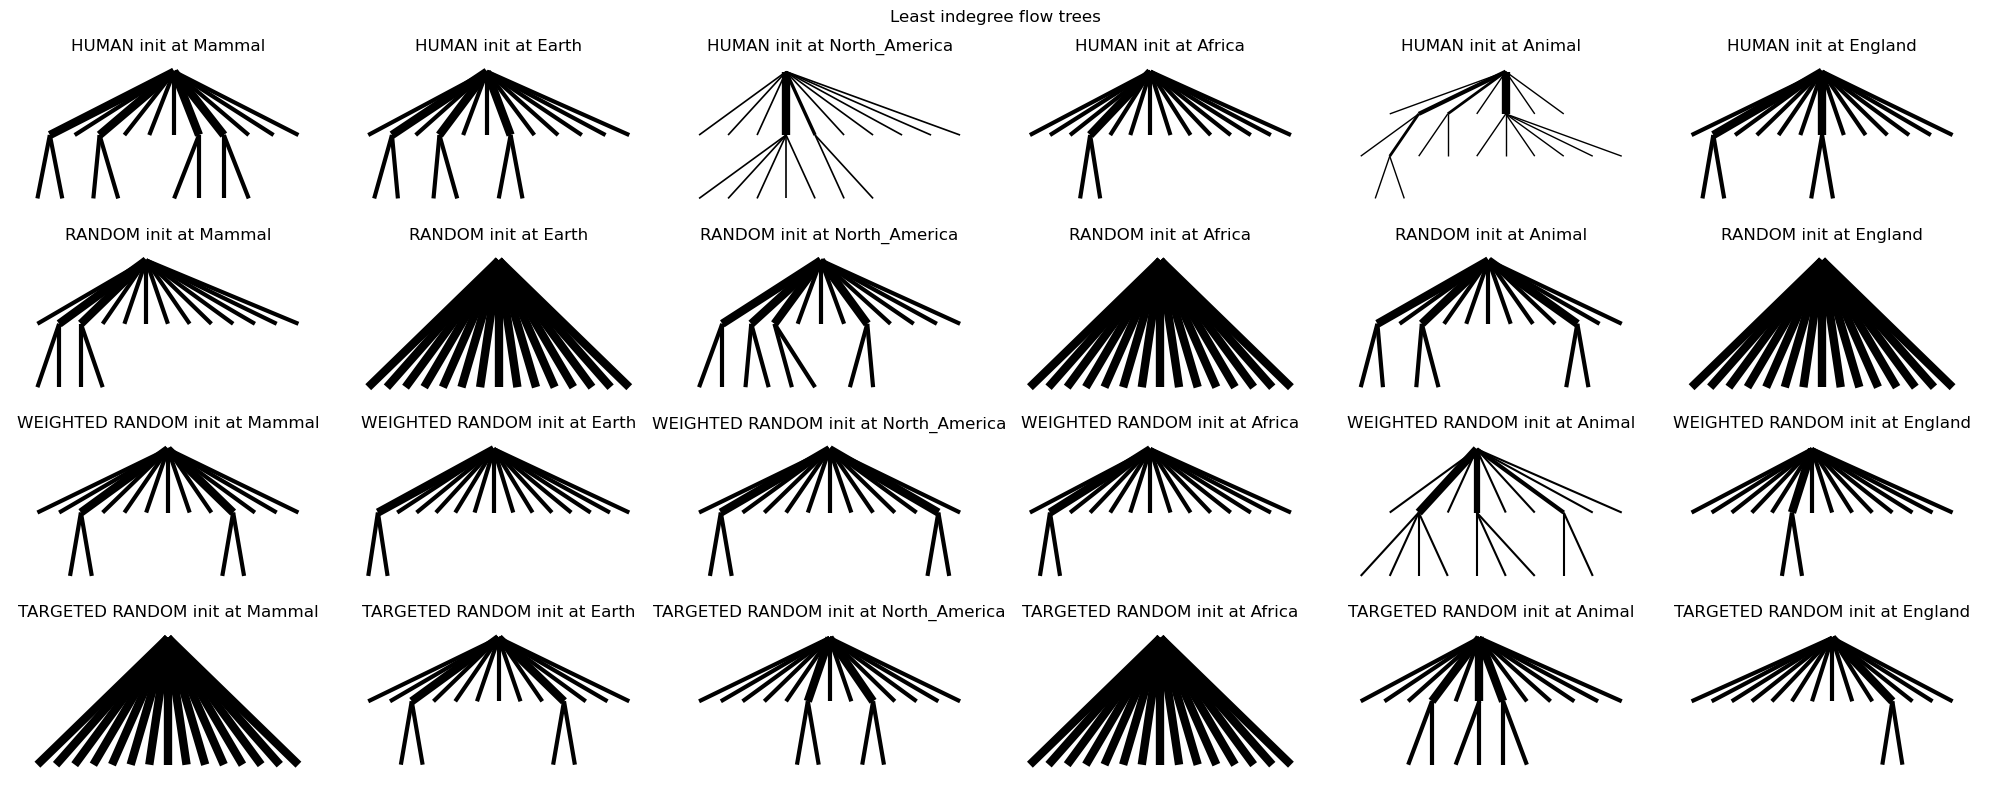

In [ ]:
print("Most indegree:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in most_indegree_nodes},
    title_str="Most indegree flow trees",
)
print("Least indegree:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in least_indegree_nodes},
    title_str="Least indegree flow trees",
)

Most outdegree:


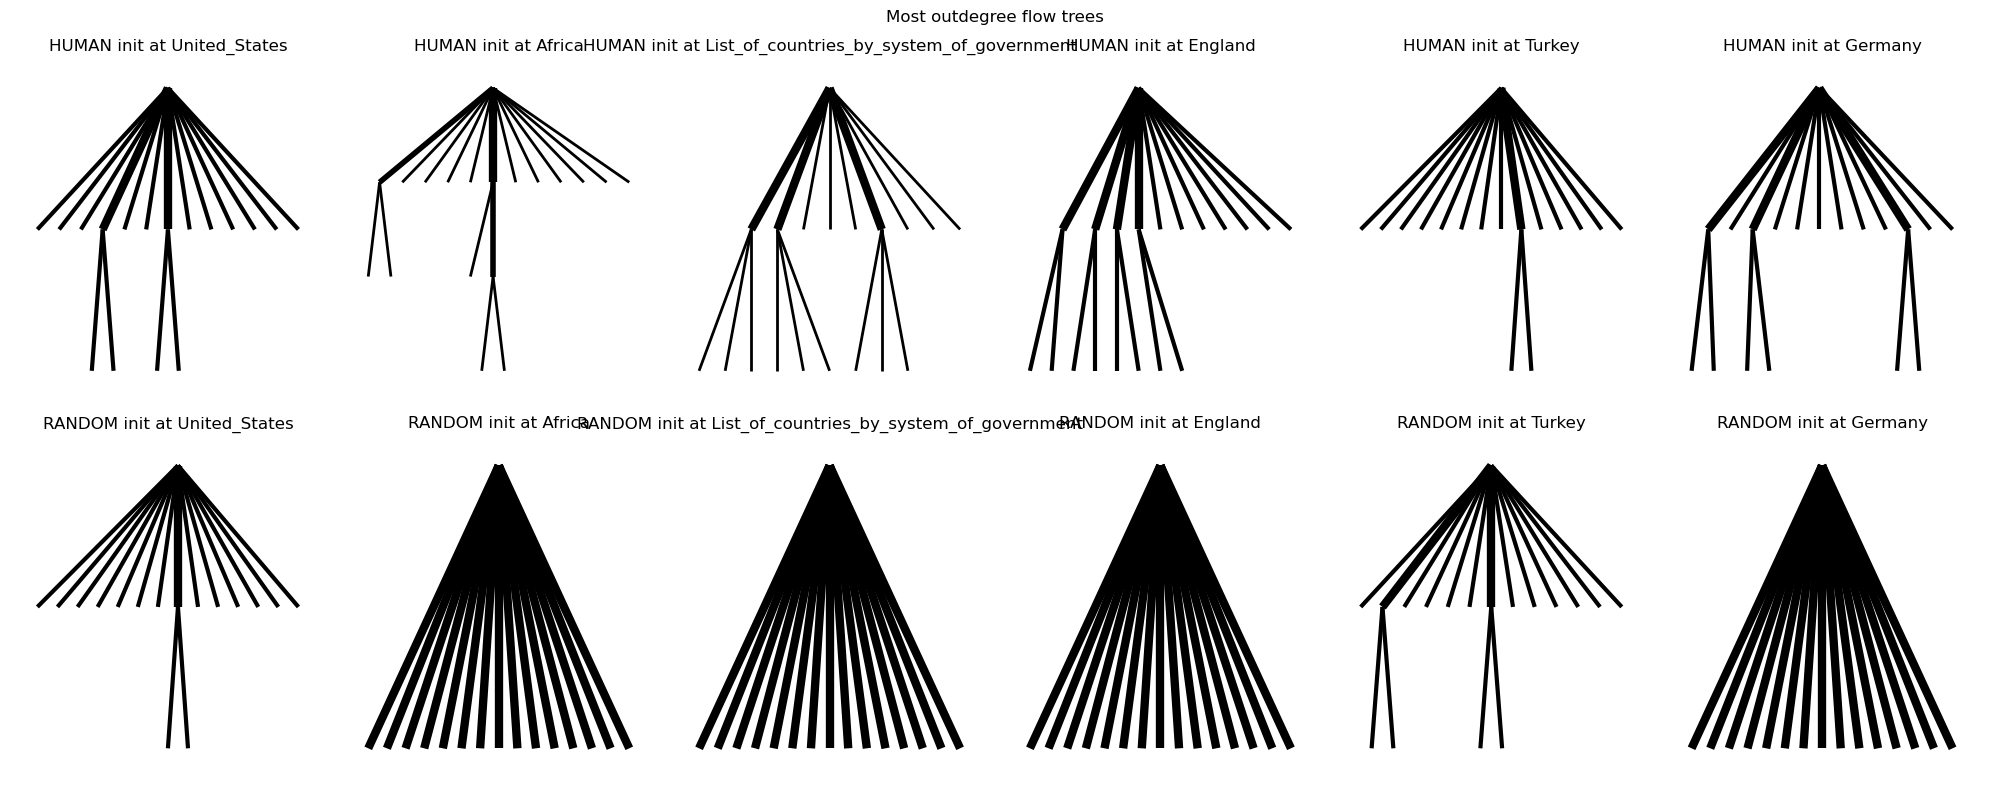

Least outdegree:


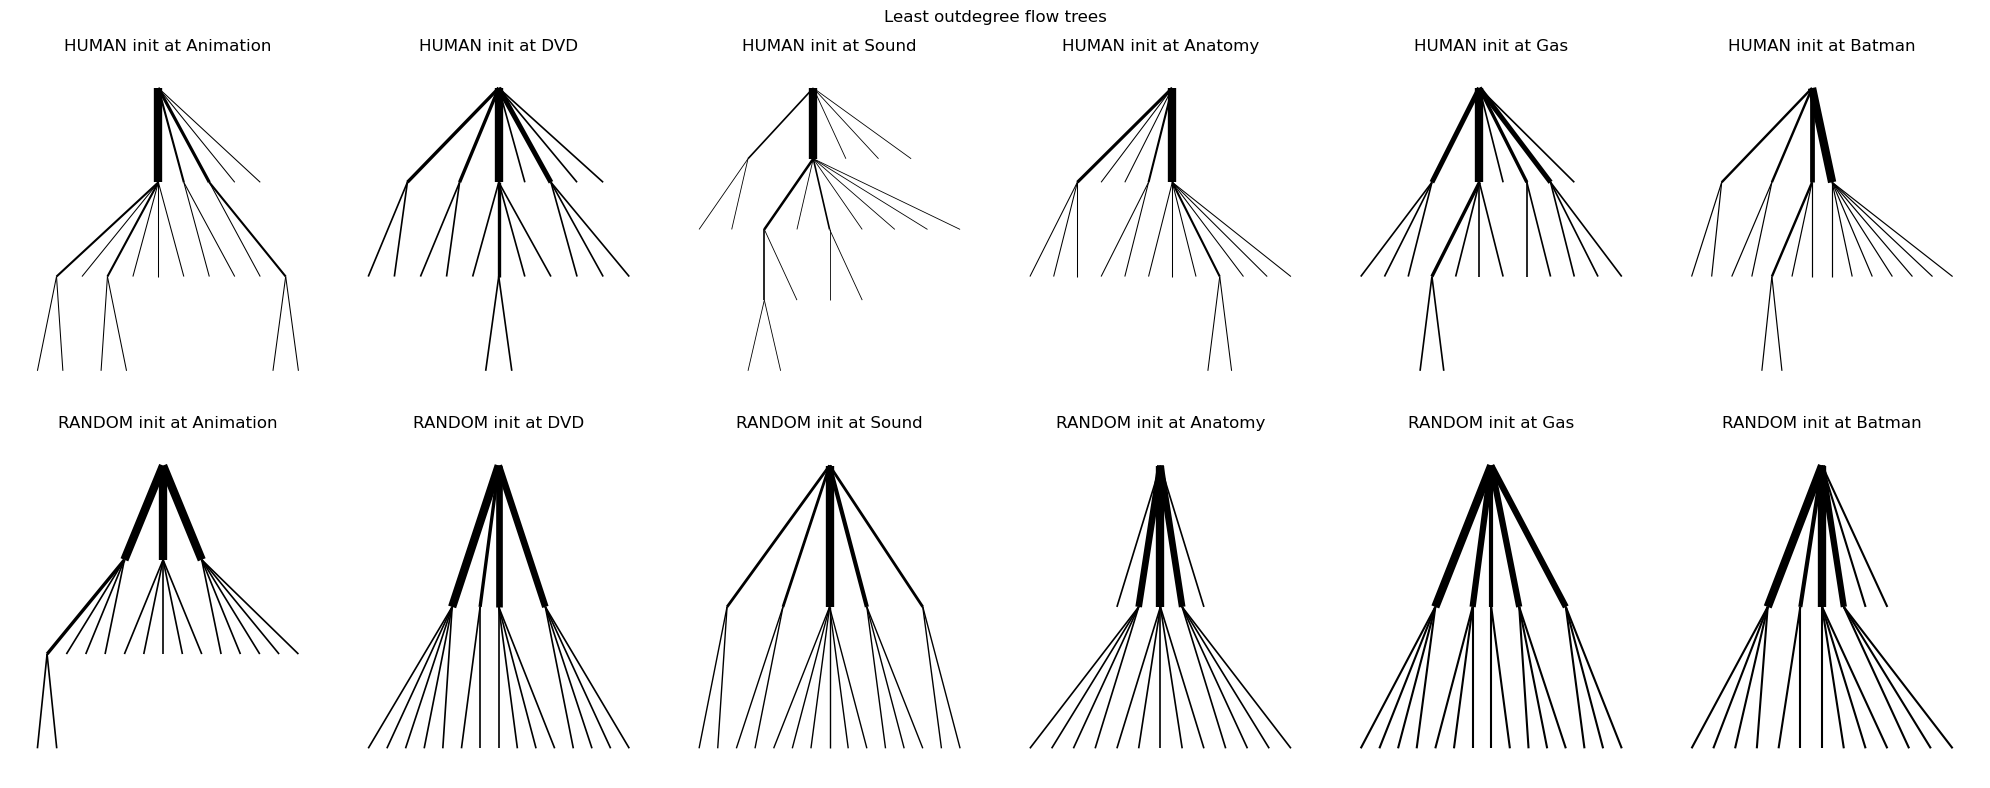

In [ ]:
print("Most outdegree:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in most_outdegree_nodes},
    title_str="Most outdegree flow trees",
)
print("Least outdegree:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in least_outdegree_nodes},
    title_str="Least outdegree flow trees",
)

In [ ]:
human_most_outdegree_flowtrees = [
    tree
    for node in most_outdegree_nodes
    for tree in most_common_flow_tree_dict[node]["human"]
]
random_most_outdegree_flowtrees = [
    tree
    for node in most_outdegree_nodes
    for tree in most_common_flow_tree_dict[node]["random"]
]

results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
    human_most_outdegree_flowtrees,
    random_most_outdegree_flowtrees,
    normalise=False,
    group1_name="human most outdegree",
    group2_name="random most outdegree",
)
results_df

/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,group1_name,group2_name,group1_mean,group2_mean,group1_var,group2_var,group1_n,group2_n,statistic,p_value,metric,notes
0,human most outdegree,random most outdegree,18.22800,16.8520,1.384016,0.774096,250,250,14.780227,2.999921e-41,num_nodes,Comparing flow tree num_nodes between human mo...
1,human most outdegree,random most outdegree,14.98400,15.0000,0.015744,0.000000,250,250,-2.012158,4.474123e-02,num_leaves,Comparing flow tree num_leaves between human m...
2,human most outdegree,random most outdegree,2.13200,1.5840,0.218576,0.250944,250,250,12.619821,7.109047e-32,depth,Comparing flow tree depth between human most o...
3,human most outdegree,random most outdegree,6.72039,10.6944,5.551120,14.257949,250,250,-14.089531,3.499117e-38,avg_branching_factor,Comparing flow tree avg_branching_factor betwe...
4,human most outdegree,random most outdegree,3.82400,2.8080,0.553024,0.619136,250,250,14.808120,2.249322e-41,diameter,Comparing flow tree diameter between human mos...


In [ ]:
human_least_outdegree_flowtrees = [
    tree
    for node in least_outdegree_nodes
    for tree in most_common_flow_tree_dict[node]["human"]
]
random_least_outdegree_flowtrees = [
    tree
    for node in least_outdegree_nodes
    for tree in most_common_flow_tree_dict[node]["random"]
]

results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
    human_least_outdegree_flowtrees,
    random_least_outdegree_flowtrees,
    normalise=False,
    group1_name="human least outdegree",
    group2_name="random least outdegree",
)
results_df

/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,group1_name,group2_name,group1_mean,group2_mean,group1_var,group2_var,group1_n,group2_n,statistic,p_value,metric,notes
0,human least outdegree,random least outdegree,20.37200,20.496000,1.617616,1.025984,250,250,-1.203437,2.293789e-01,num_nodes,Comparing flow tree num_nodes between human le...
1,human least outdegree,random least outdegree,14.98000,15.000000,0.019600,0.000000,250,250,-2.254248,2.461441e-02,num_leaves,Comparing flow tree num_leaves between human l...
2,human least outdegree,random least outdegree,2.71200,2.228000,0.365056,0.176016,250,250,10.382872,5.412902e-23,depth,Comparing flow tree depth between human least ...
3,human least outdegree,random least outdegree,4.55487,4.452295,0.463030,0.234910,250,250,1.937450,5.325539e-02,avg_branching_factor,Comparing flow tree avg_branching_factor betwe...
4,human least outdegree,random least outdegree,4.83600,4.252000,0.625104,0.236496,250,250,9.927952,2.577825e-21,diameter,Comparing flow tree diameter between human lea...


In [ ]:
results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
    human_least_outdegree_flowtrees,
    human_most_outdegree_flowtrees,
    normalise=False,
    group1_name="human least outdegree",
    group2_name="human most outdegree",
)
results_df[
    (results_df.group1_mean > results_df.group2_mean) & (results_df.p_value < 0.05)
][["group2_mean", "group1_mean", "metric"]]

0    num_nodes
2        depth
4     diameter
Name: metric, dtype: object

In [ ]:
results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
    random_least_outdegree_flowtrees,
    random_most_outdegree_flowtrees,
    normalise=False,
    group1_name="random least outdegree",
    group2_name="random most outdegree",
)
results_df

/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,group1_name,group2_name,group1_mean,group2_mean,group1_var,group2_var,group1_n,group2_n,statistic,p_value,metric,notes
0,random least outdegree,random most outdegree,20.526667,16.832000,1.595956,0.699776,300,250,39.501665,1.824844e-162,num_nodes,Comparing flow tree num_nodes between random l...
1,random least outdegree,random most outdegree,14.940000,15.000000,0.176400,0.000000,300,250,-2.254659,2.454870e-02,num_leaves,Comparing flow tree num_leaves between random ...
2,random least outdegree,random most outdegree,2.300000,1.608000,0.223333,0.254336,300,250,16.553913,3.278584e-50,depth,Comparing flow tree depth between random least...
3,random least outdegree,random most outdegree,4.411817,10.644133,0.251411,13.428983,300,250,-29.078570,3.762639e-113,avg_branching_factor,Comparing flow tree avg_branching_factor betwe...
4,random least outdegree,random most outdegree,4.346667,2.796000,0.339822,0.562384,300,250,27.218485,7.634944e-104,diameter,Comparing flow tree diameter between random le...


### Landmark testing

In [ ]:
big_k = 500
small_k = 50
most_common_nodes = find_k_most_x_nodes(node_counts, k=big_k, verbose_str="common")
if "Wikipedia_Text_of_the_GNU_Free_Documentation_License" in most_common_nodes:
    most_common_nodes.remove("Wikipedia_Text_of_the_GNU_Free_Documentation_License")

outdegree_landmarks = find_k_most_x_nodes(
    node_outdegrees, k=small_k, restrict_to=most_common_nodes, verbose_str="outdegree"
)
player_landmarks = find_k_most_x_nodes(
    node_counts, k=small_k, restrict_to=most_common_nodes, verbose_str="common"
)
semantic_landmarks = find_k_most_x_nodes(
    node_zipf_frequencies, k=small_k, restrict_to=most_common_nodes, verbose_str="zipf"
)


print()
print(
    "Most outdegree, most player overlap",
    len(set(outdegree_landmarks).intersection(set(player_landmarks))),
)
print(
    "Most player, most zipf overlap",
    len(set(player_landmarks).intersection(set(semantic_landmarks))),
)
print(
    "Most outdegree, most zipf overlap",
    len(set(outdegree_landmarks).intersection(set(semantic_landmarks))),
)

print(
    set(outdegree_landmarks)
    .intersection(set(player_landmarks))
    .intersection(set(semantic_landmarks))
)

Most common node is United_States with 12660; 500th most is Nintendo_Entertainment_System with 173
Most outdegree node is United_States with 294; 50th most is NATO with 96
Most common node is United_States with 12660; 50th most is Water with 1093
Most zipf node is Time with 6.29; 50th most is Black_Sea with 5.26

Most outdegree, most player overlap 20
Most player, most zipf overlap 8
Most outdegree, most zipf overlap 9
{'Water', 'London', 'World_War_II', 'Human', 'United_States', 'South_America'}


In [16]:
most_common_nodes = set(most_common_nodes)
outdegree_landmarks = set(outdegree_landmarks)
player_landmarks = set(player_landmarks)
semantic_landmarks = set(semantic_landmarks)

In [ ]:
min_path_length = 5
traj_per_tree = 15

most_common_flow_tree_dict = make_flow_tree_dict_from_node_list(
    most_common_nodes,
    trajs_df,
    min_path_length=min_path_length,
    wikiG=wikiG,
    k_fold=5,
    traj_per_tree=traj_per_tree,
    plot_title_str=None,
)

rev_wikiG = wikiG.reverse()
rev_traj_dict = make_rev_traj_dict(
    most_common_nodes, trajs_df, min_path_length=min_path_length
)
most_common_rev_flow_tree_dict = sample_flow_trees_from_traj_dict(
    rev_traj_dict, rev_wikiG, k_fold=5, traj_per_tree=traj_per_tree
)

DiGraph with 4592 nodes and 119881 edges


### Landmark vs. Non-Landmark Flow Tree Examples

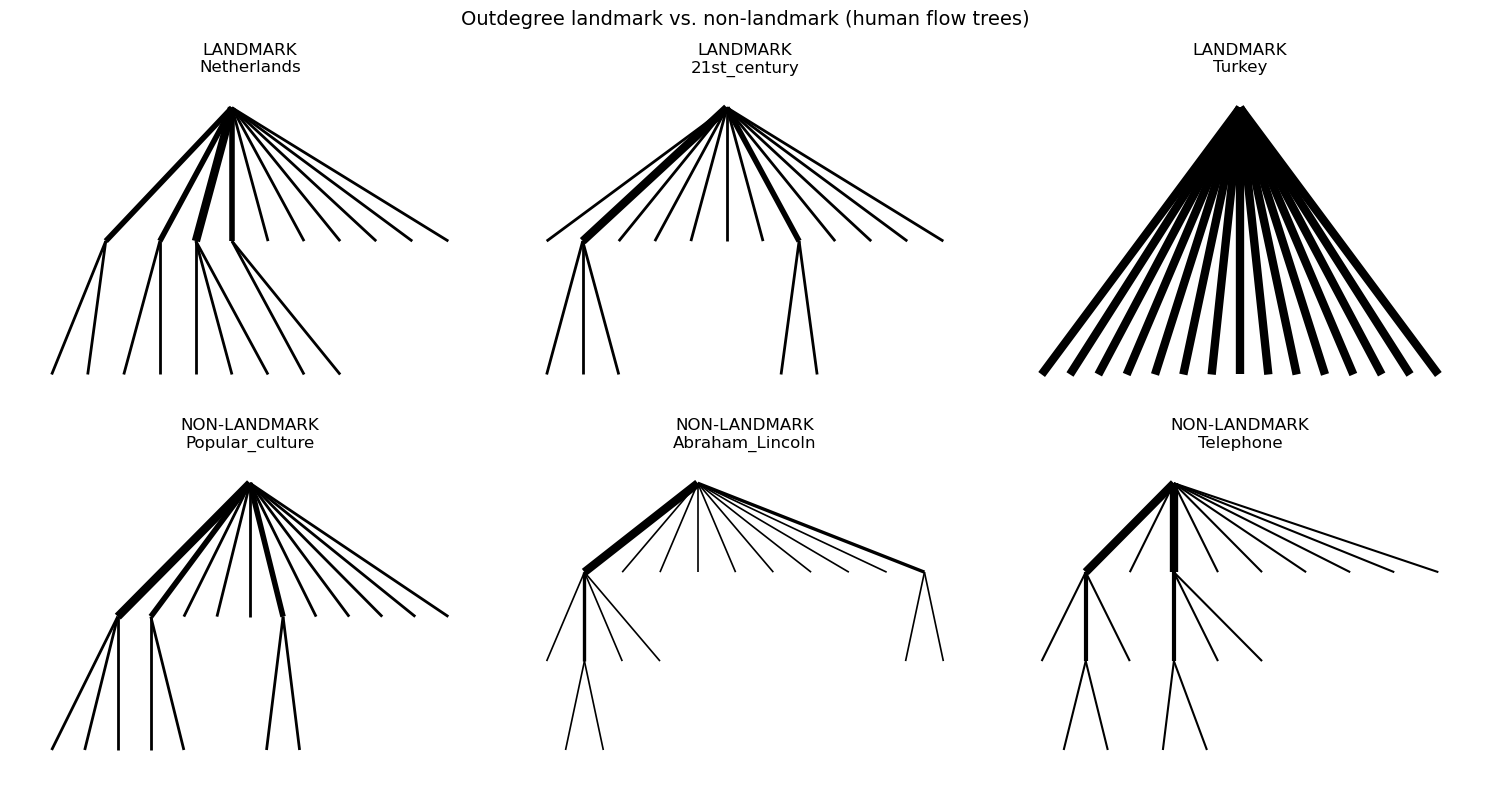

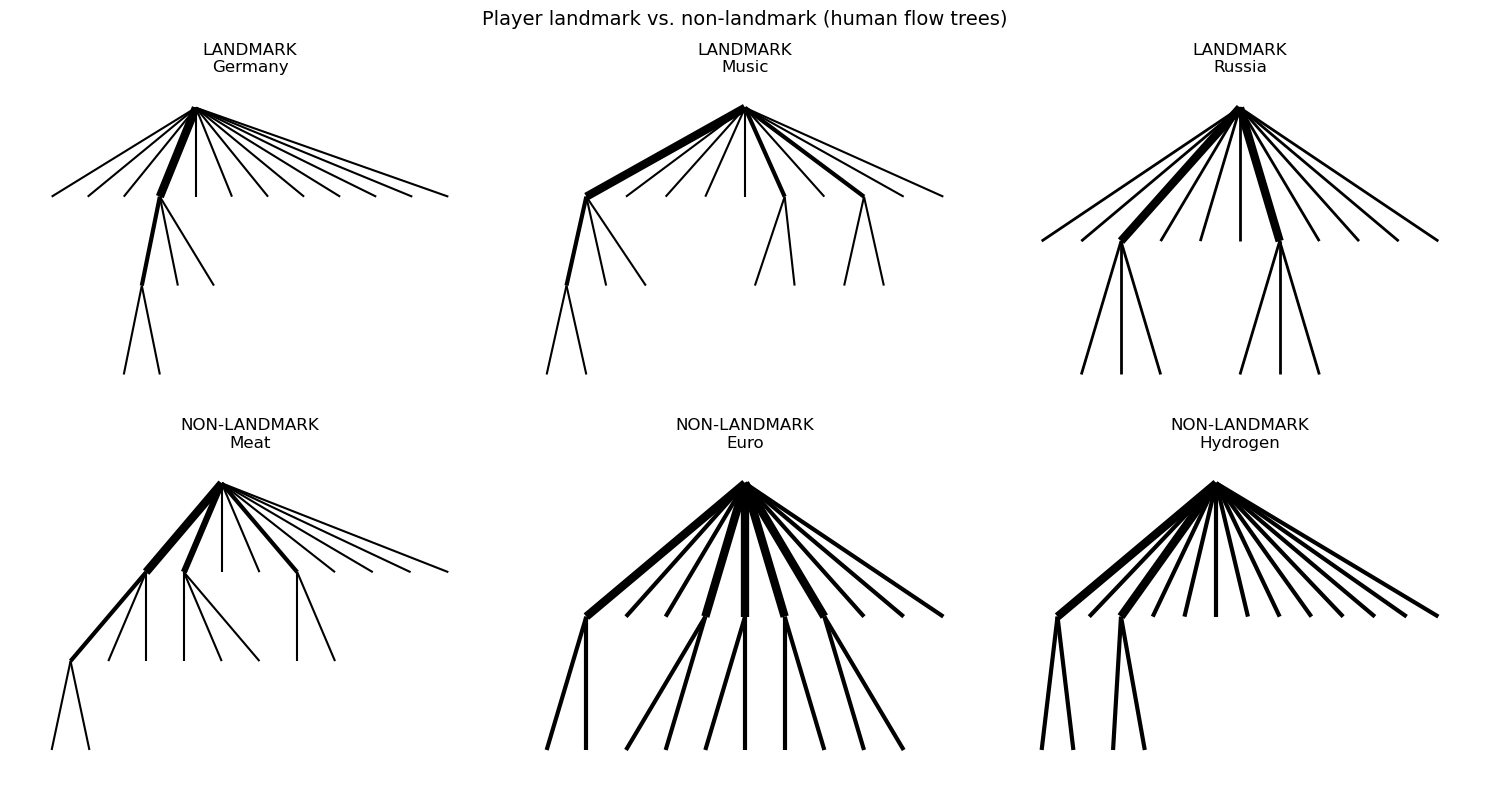

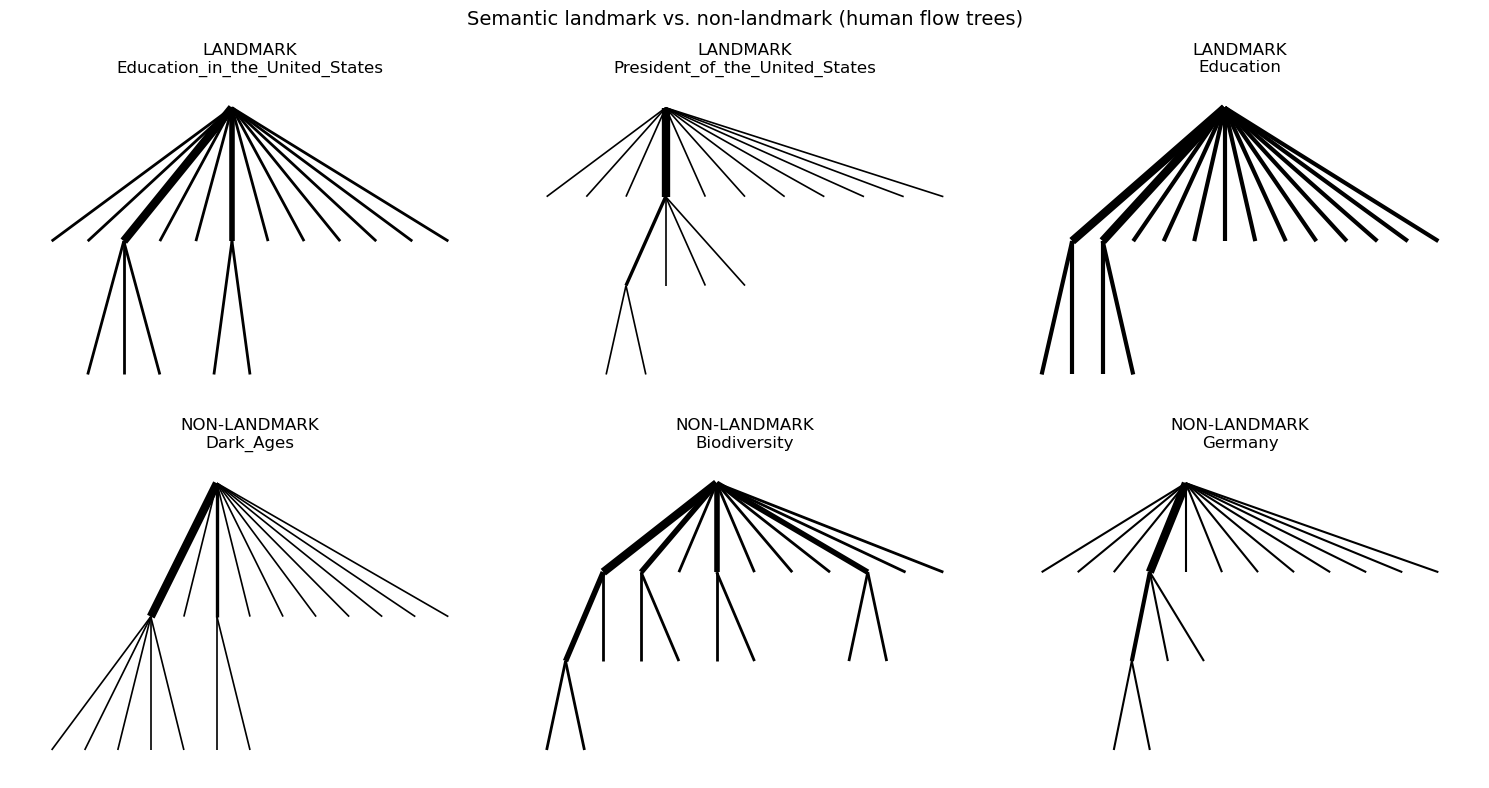

In [ ]:
def plot_landmark_vs_nonlandmark(
    flow_tree_dict,
    landmark_nodes,
    all_nodes,
    landmark_type_str,
    n_examples=3,
    person="human",
):
    non_landmark_nodes = [n for n in all_nodes if n not in landmark_nodes]

    landmark_sample = random.sample(
        sorted(landmark_nodes), min(n_examples, len(landmark_nodes))
    )
    non_landmark_sample = random.sample(
        non_landmark_nodes, min(n_examples, len(non_landmark_nodes))
    )

    fig, axes = plt.subplots(2, n_examples, figsize=(5 * n_examples, 8))
    fig.suptitle(
        f"{landmark_type_str} landmark vs. non-landmark (human flow trees)", fontsize=14
    )

    for j, node in enumerate(landmark_sample):
        G = flow_tree_dict[node][person][0]
        plot_flow_tree(
            G, f"LANDMARK\n{node}", axes[0][j], just_edges=True, no_title=False
        )

    for j, node in enumerate(non_landmark_sample):
        G = flow_tree_dict[node][person][0]
        plot_flow_tree(
            G, f"NON-LANDMARK\n{node}", axes[1][j], just_edges=True, no_title=False
        )

    axes[0][0].set_ylabel("Landmark", fontsize=12)
    axes[1][0].set_ylabel("Non-Landmark", fontsize=12)
    plt.tight_layout()
    plt.show()


plot_landmark_vs_nonlandmark(
    most_common_flow_tree_dict, outdegree_landmarks, most_common_nodes, "Outdegree"
)
    
# plot_landmark_vs_nonlandmark(most_common_flow_tree_dict, player_landmarks, most_common_nodes, "Player")
# plot_landmark_vs_nonlandmark(most_common_flow_tree_dict, semantic_landmarks, most_common_nodes, "Semantic")


outdegree human
                 metric  group1_mean  group2_mean direction       p_value
0             num_nodes    30.588000    32.028444      less  3.012137e-25
1            num_leaves    24.892000    24.709333      more  3.702452e-03
2                 depth     2.404000     2.721333      less  8.167557e-17
3  avg_branching_factor     6.420968     5.300550      more  1.223679e-56
4              diameter     4.480000     4.976889      less  2.358459e-18
player human
                 metric  group1_mean  group2_mean direction       p_value
0             num_nodes    31.436000    31.934222      less  3.753328e-04
1            num_leaves    24.868000    24.712000      more  1.320558e-02
2                 depth     2.612000     2.698222      less  2.454323e-02
3  avg_branching_factor     5.918959     5.356329      more  5.504497e-15
4              diameter     4.812000     4.940000      less  2.540897e-02
(250, 5)
(2500,)
semantic human
                 metric  group1_mean  group2_mean d

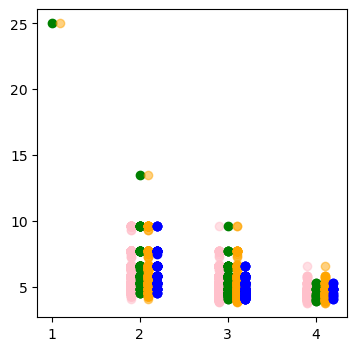

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
for person in ["human", "random"]:
    outdegree_landmark_flowtrees = [
        tree
        for node in outdegree_landmarks
        for tree in most_common_flow_tree_dict[node][person]
    ]
    outdegree_non_landmark_flowtrees = [
        tree
        for node in (most_common_nodes - outdegree_landmarks)
        for tree in most_common_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        outdegree_landmark_flowtrees,
        outdegree_non_landmark_flowtrees,
        normalise=False,
        group1_name="outdegree landmark",
        group2_name="outdegree not landmark",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("outdegree", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    player_landmark_flowtrees = [
        tree
        for node in player_landmarks
        for tree in most_common_flow_tree_dict[node][person]
    ]
    player_non_landmark_flowtrees = [
        tree
        for node in (most_common_nodes - player_landmarks)
        for tree in most_common_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        player_landmark_flowtrees,
        player_non_landmark_flowtrees,
        normalise=False,
        group1_name="player landmark",
        group2_name="player not landmark",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("player", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    print(group1_features.shape)
    feature_names = [
        "num_nodes",
        "num_leaves",
        "depth",
        "avg_branching_factor",
        "diameter",
    ]
    depths = np.concatenate((group1_features[:, 2], group2_features[:, 2]))
    avg_branching_factors = np.concatenate(
        (group1_features[:, 3], group2_features[:, 3])
    )

    ax.scatter(group2_features[:, 2] - 0.1, group2_features[:, 3], c="pink", alpha=0.5)
    ax.scatter(group1_features[:, 2], group1_features[:, 3], c="green")
    print(depths.shape)

    semantic_landmark_flowtrees = [
        tree
        for node in semantic_landmarks
        for tree in most_common_flow_tree_dict[node][person]
    ]
    semantic_non_landmark_flowtrees = [
        tree
        for node in (most_common_nodes - semantic_landmarks)
        for tree in most_common_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        semantic_landmark_flowtrees,
        semantic_non_landmark_flowtrees,
        normalise=False,
        group1_name="semantic landmark",
        group2_name="semantic not landmark",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("semantic", person)
    print(
        results_df[results_df.p_value < 1][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    ax.scatter(
        group2_features[:, 2] + 0.1, group2_features[:, 3], c="orange", alpha=0.5
    )
    ax.scatter(group1_features[:, 2] + 0.2, group1_features[:, 3], c="blue")
    break

    print()
    print("----------------")
    print()
plt.show()

In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms


def confidence_ellipse(x, y, ax, n_std=3.0, **kwargs):
    """
    Create a plot of the covariation confidence ellipse.

    Parameters
    ----------
    x, y : array_like, shape (n, )
        Input data.
    ax : matplotlib.axes.Axes
        The axes object to draw the ellipse on.
    n_std : float
        The number of standard deviations for the ellipse radius.
    **kwargs
        Forwarded to matplotlib.patches.Ellipse

    Returns
    -------
    matplotlib.patches.Ellipse
    """
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a t-distribution for small sample sizes would be more accurate,
    # but a chi-squared distribution works well for larger samples.
    # The following two lines assume normal distribution:
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)

    # Calculate the center of the ellipse
    center_x = np.mean(x)
    center_y = np.mean(y)

    ellipse = Ellipse(
        (center_x, center_y), width=ell_radius_x * 2, height=ell_radius_y * 2, **kwargs
    )

    # Calculating the rotation angle
    angle = 180.0 + np.arctan2(cov[0, 1], cov[0, 0] - cov[1, 1]) / np.pi * 180
    ellipse.set_angle(angle)

    # Scale the ellipse to the data's standard deviation
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std

    trans = (
        transforms.Affine2D()
        .rotate_deg(angle)
        .scale(scale_x, scale_y)
        .translate(center_x, center_y)
    )
    ellipse.set_transform(trans + ax.transData)
    return ax.add_patch(ellipse)

In [ ]:
## feature pca
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features_dict = {
    "human": None,
    "random": None,
    "weighted_random": None,
    "targeted_random": None,
}
labels_dict = {}
trees_dict = {}

for group in features_dict:
    trees = [
        G
        for node in most_common_flow_tree_dict
        for G in most_common_flow_tree_dict[node][group]
    ]

    features = np.array(
        [
            extract_tree_features(G, 0)
            for node in most_common_flow_tree_dict
            for G in most_common_flow_tree_dict[node][group]
        ]
    )
    labels = np.array(
        [
            "landmark" if node in outdegree_landmarks else "non-landmark"
            for node in most_common_flow_tree_dict
            for G in most_common_flow_tree_dict[node][group]
        ]
    )

    features_dict[group] = features
    labels_dict[group] = labels
    trees_dict[group] = trees

all_features = np.concatenate(list(features_dict.values()))

scaler = StandardScaler()
all_scaled = scaler.fit_transform(all_features)

pca = PCA(n_components=3)  # 0.95

X_pca = pca.fit_transform(all_scaled)

print("Original shape:", all_scaled.shape)
print("Transformed shape:", X_pca.shape)
print("Number of components chosen:", pca.n_components_)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.sum(pca.explained_variance_ratio_))

Original shape: (10000, 5)
Transformed shape: (10000, 3)
Number of components chosen: 3
Explained variance ratio: [0.65509177 0.21222639 0.08645199]
Cumulative explained variance: 0.9537701429886482


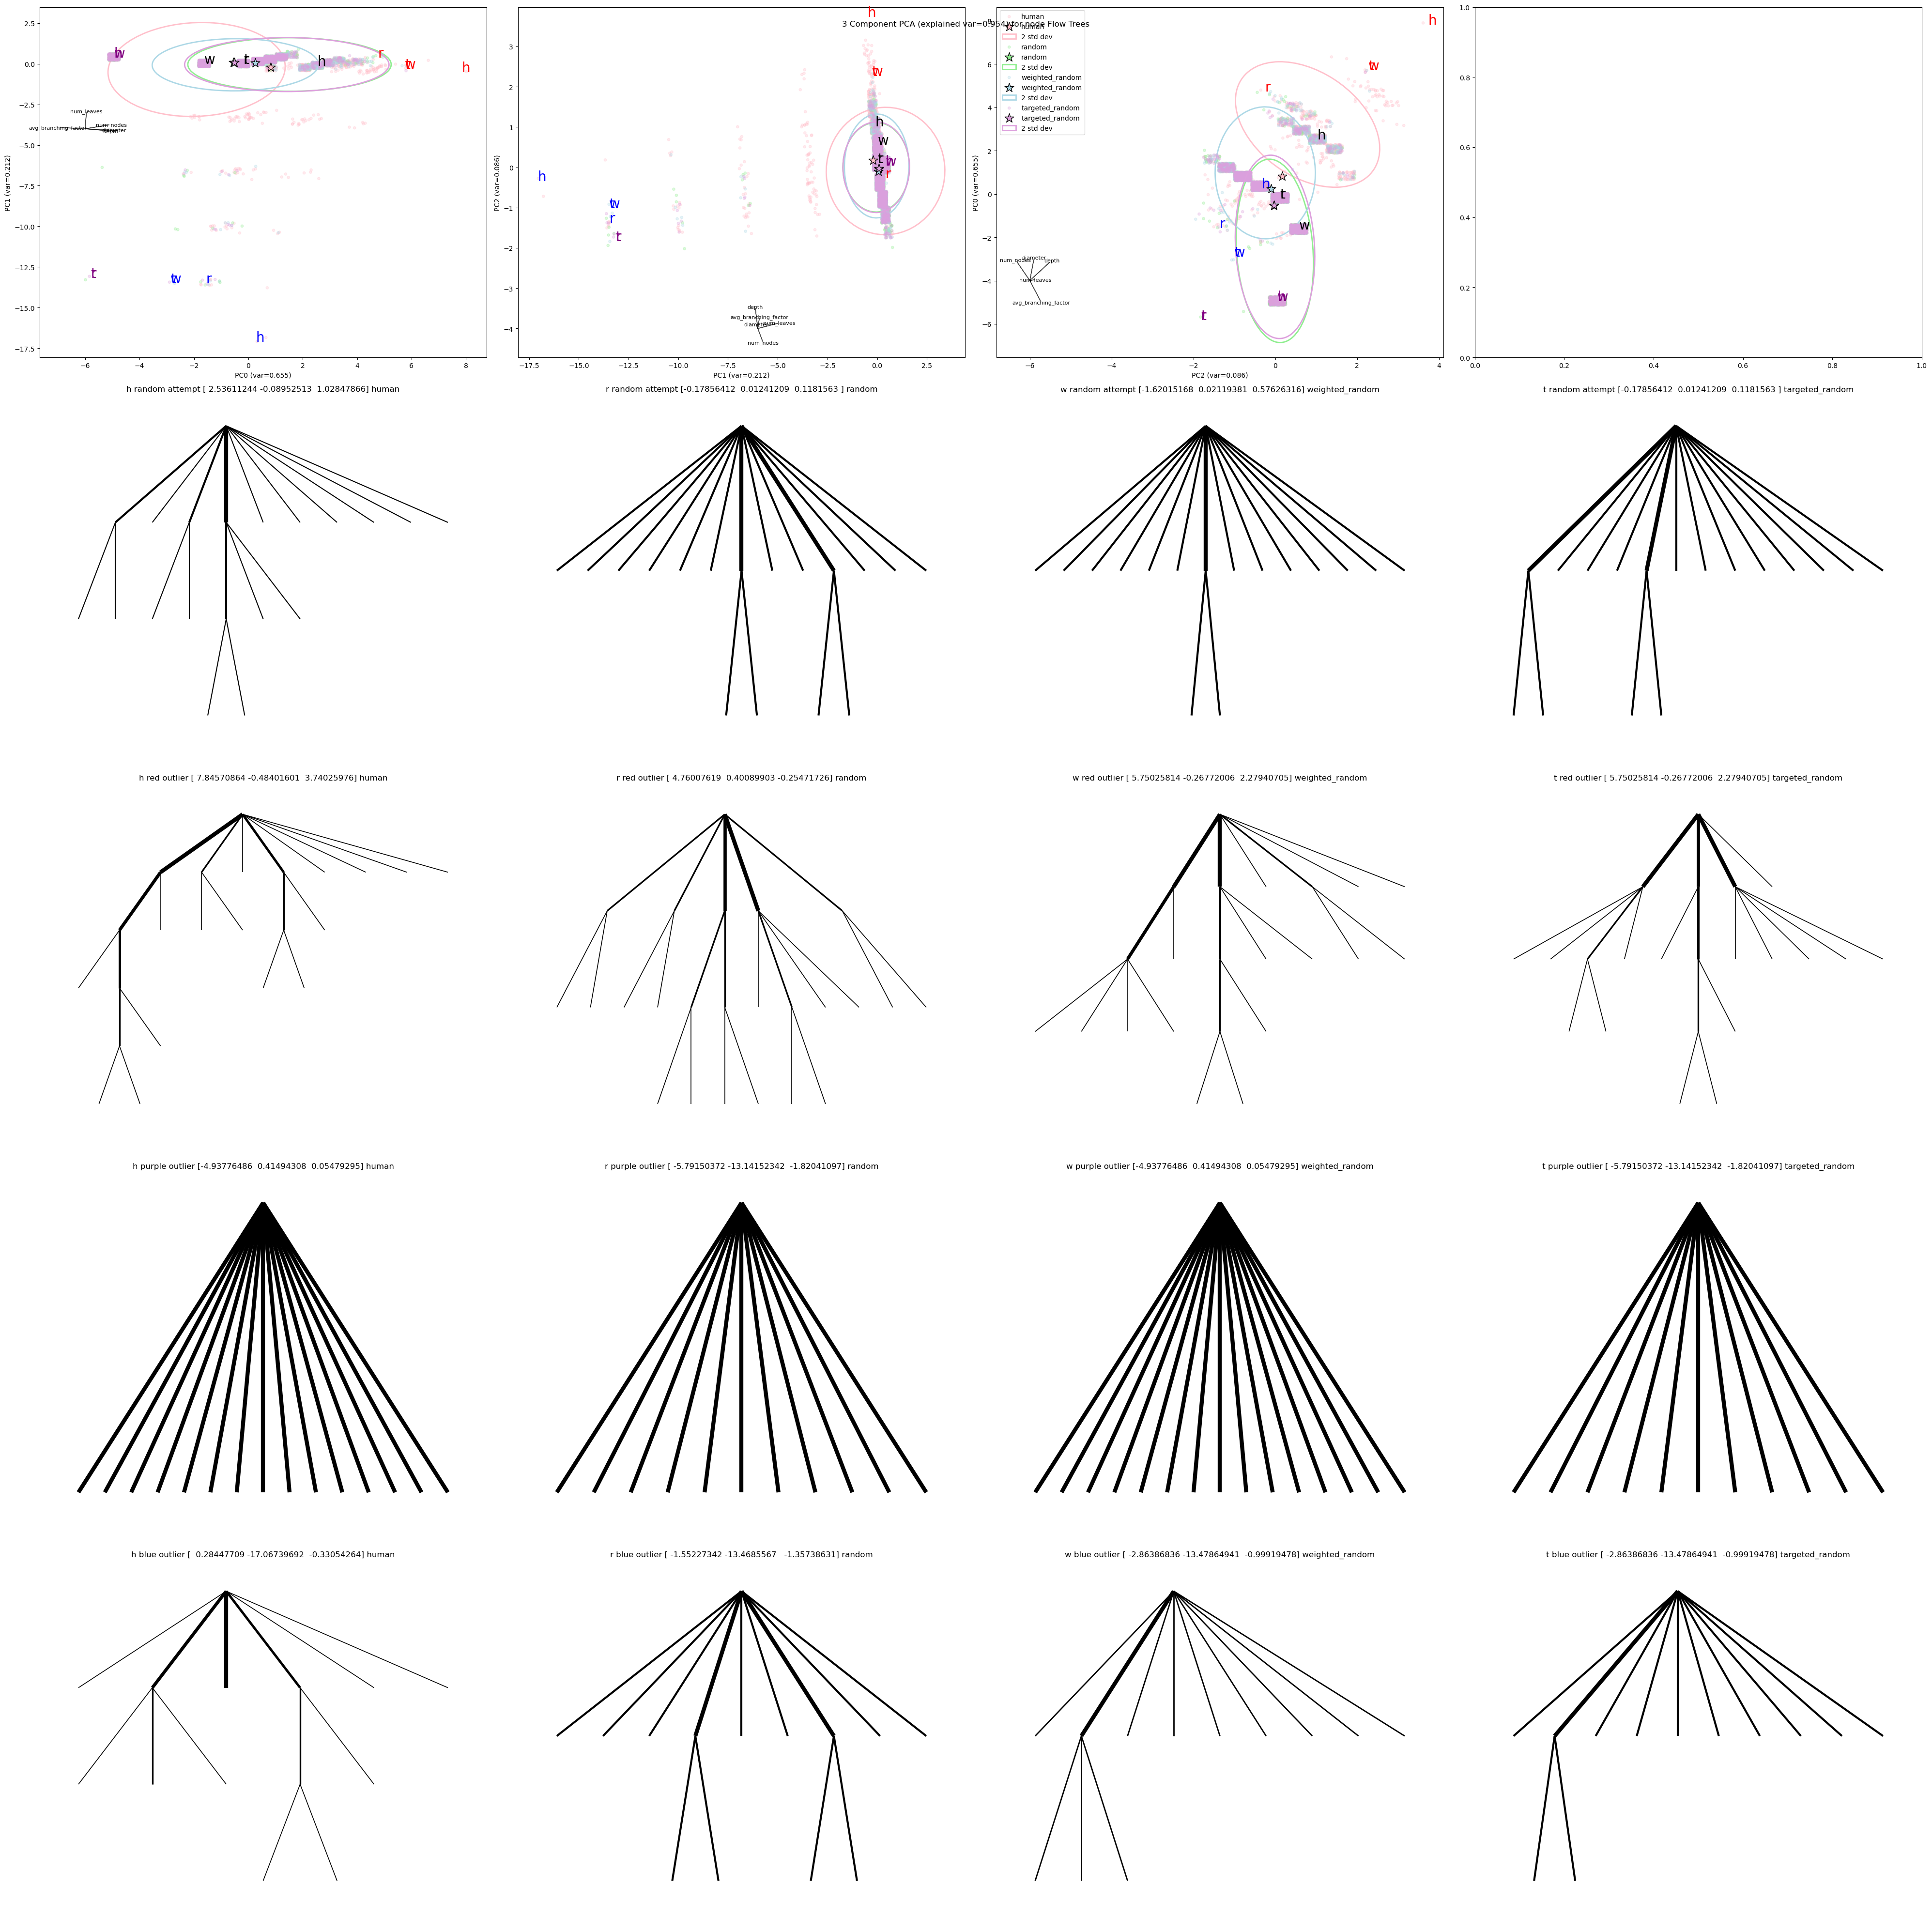

In [ ]:
# pca_2d = PCA(n_components=2)
# X_pca_2d = pca_2d.fit_transform(X_scaled)
# n_group1 = human_features.shape[0]
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
colors = ["pink", "lightgreen", "lightblue", "plum"]
fig, axes = plt.subplots(5, 4, figsize=(40, 40))

ccs = ["red", "purple", "blue", "green"]
for j, group in enumerate(features_dict):
    features = features_dict[group]
    labels = labels_dict[group]

    scaled_features = scaler.transform(features)
    featuers_pca = pca.transform(scaled_features)

    max_0_idx = np.argmax(featuers_pca[:, 0])
    min_0_idx = np.argmin(featuers_pca[:, 0])
    min_1_idx = np.argmin(featuers_pca[:, 1])
    outliers = [max_0_idx, min_0_idx, min_1_idx]

    for ii, idx in enumerate(outliers):
        feat = featuers_pca[idx, :]
        outlier_G = trees_dict[group][idx]
        axes[0, 0].annotate(
            group[0], (feat[0], feat[1]), c=ccs[ii], alpha=1, fontsize=20, zorder=10
        )
        axes[0, 1].annotate(
            group[0], (feat[1], feat[2]), c=ccs[ii], alpha=1, fontsize=20, zorder=10
        )
        axes[0, 2].annotate(
            group[0], (feat[2], feat[0]), c=ccs[ii], alpha=1, fontsize=20, zorder=10
        )
        plot_flow_tree(
            outlier_G,
            f"{group[0]} {ccs[ii]} outlier {feat} {group}",
            axes[ii + 2, j],
            just_edges=True,
            no_title=False,
        )

    rand_idx = np.random.randint(len(scaled_features))
    feat = featuers_pca[rand_idx, :]
    outlier_G = trees_dict[group][rand_idx]
    axes[0, 0].annotate(
        group[0], (feat[0], feat[1]), c="black", alpha=1, fontsize=20, zorder=10
    )
    axes[0, 1].annotate(
        group[0], (feat[1], feat[2]), c="black", alpha=1, fontsize=20, zorder=10
    )
    axes[0, 2].annotate(
        group[0], (feat[2], feat[0]), c="black", alpha=1, fontsize=20, zorder=10
    )
    plot_flow_tree(
        outlier_G,
        f"{group[0]} random attempt {feat} {group}",
        axes[1, j],
        just_edges=True,
        no_title=False,
    )

    for i in range(3):
        ax = axes[0, i]
        jitter_width = 0.2
        n_group = len(features)

        ax.scatter(
            featuers_pca[:, i]
            + np.random.uniform(-jitter_width, jitter_width, size=n_group),
            featuers_pca[:, (i + 1) % 3]
            + np.random.uniform(-jitter_width, jitter_width, size=n_group),
            c=[colors[j] if l == "landmark" else colors[j] for l in labels],
            alpha=0.3,
            s=15,
            label=group,
        )

        ax.scatter(
            featuers_pca[:, i].mean(),
            featuers_pca[:, (i + 1) % 3].mean(),
            c=colors[j],
            alpha=1,
            s=200,
            marker="*",
            edgecolors="black",
            label=group,
            zorder=10,
        )

        confidence_ellipse(
            featuers_pca[:, i],
            featuers_pca[:, (i + 1) % 3],
            ax,
            n_std=2.0,
            edgecolor=colors[j],
            facecolor="none",
            linewidth=2,
            label="2 std dev",
        )

        # ax.scatter(featuers_pca[:, i][[l=="landmark" for l in labels]].mean(), featuers_pca[:, (i+1)%3][[l=="landmark" for l in labels]].mean(), c=colors[j], edgecolors='black', alpha=1, s=200, marker="^", label=group + " landmark", zorder=10)

for i in range(3):
    # Plot the loadings as arrows
    for j, feature in enumerate(feature_names):
        axes[0, i].arrow(
            -6, -4, loadings[j, i], loadings[j, (i + 1) % 3], color="k", alpha=0.7
        )
        axes[0, i].annotate(
            feature,
            (-6 + loadings[j, i] * 1.1, -4 + loadings[j, (i + 1) % 3] * 1.1),
            color="k",
            fontsize=8,
            ha="center",
            va="center",
        )

    axes[0, i].set_xlabel(f"PC{i} (var={pca.explained_variance_ratio_[i]:0.3f})")
    axes[0, i].set_ylabel(
        f"PC{(i + 1) % 3} (var={pca.explained_variance_ratio_[(i + 1) % 3]:0.3f})"
    )

axes[0, 2].legend()
plt.suptitle(
    f"3 Component PCA (explained var={np.sum(pca.explained_variance_ratio_):0.3f}) for node Flow Trees"
)
plt.tight_layout()
plt.show()


In [ ]:
for person in ["human", "random"]:
    outdegree_landmark_rev_flowtrees = [
        tree
        for node in outdegree_landmarks
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]
    outdegree_non_landmark_rev_flowtrees = [
        tree
        for node in (most_common_nodes - outdegree_landmarks)
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        outdegree_landmark_rev_flowtrees,
        outdegree_non_landmark_rev_flowtrees,
        normalise=False,
        group1_name="outdegree landmark rev",
        group2_name="outdegree not landmark rev",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("rev outdegree", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    player_landmark_rev_flowtrees = [
        tree
        for node in player_landmarks
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]
    player_non_landmark_rev_flowtrees = [
        tree
        for node in (most_common_nodes - player_landmarks)
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        player_landmark_rev_flowtrees,
        player_non_landmark_rev_flowtrees,
        normalise=False,
        group1_name="player landmark rev",
        group2_name="player not landmark rev",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("rev player", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    semantic_landmark_rev_flowtrees = [
        tree
        for node in semantic_landmarks
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]
    semantic_non_landmark_rev_flowtrees = [
        tree
        for node in (most_common_nodes - semantic_landmarks)
        for tree in most_common_rev_flow_tree_dict[node][person]
    ]

    results_df, group1_features, group2_features = run_ttests_on_flow_tree_groups(
        semantic_landmark_rev_flowtrees,
        semantic_non_landmark_rev_flowtrees,
        normalise=False,
        group1_name="semantic landmark rev",
        group2_name="semantic not landmark rev",
    )
    results_df["direction"] = np.where(
        results_df["group1_mean"] < results_df["group2_mean"], "less", "more"
    )
    print("rev semantic", person)
    print(
        results_df[results_df.p_value < 0.05][
            ["metric", "group1_mean", "group2_mean", "direction", "p_value"]
        ]
    )

    print()
    print("----------------")
    print()

rev outdegree human
                 metric  group1_mean  group2_mean direction       p_value
0             num_nodes    29.148000    29.816000      less  7.375515e-08
1            num_leaves    24.964000    24.852000      more  1.336666e-02
2                 depth     2.304000     2.436444      less  4.713836e-04
3  avg_branching_factor     8.416002     7.329554      more  1.824537e-10
4              diameter     4.156000     4.434222      less  1.987876e-07
rev player human
                 metric  group1_mean  group2_mean direction       p_value
0             num_nodes    29.288000    29.800444      less  3.729940e-05
1            num_leaves    24.952000    24.853333      more  2.932846e-02
3  avg_branching_factor     8.202335     7.353294      more  6.545670e-07
4              diameter     4.272000     4.421333      less  5.337462e-03
rev semantic human
                 metric  group1_mean  group2_mean direction   p_value
3  avg_branching_factor     7.749979     7.403556      more 

Outdegree landmarks:


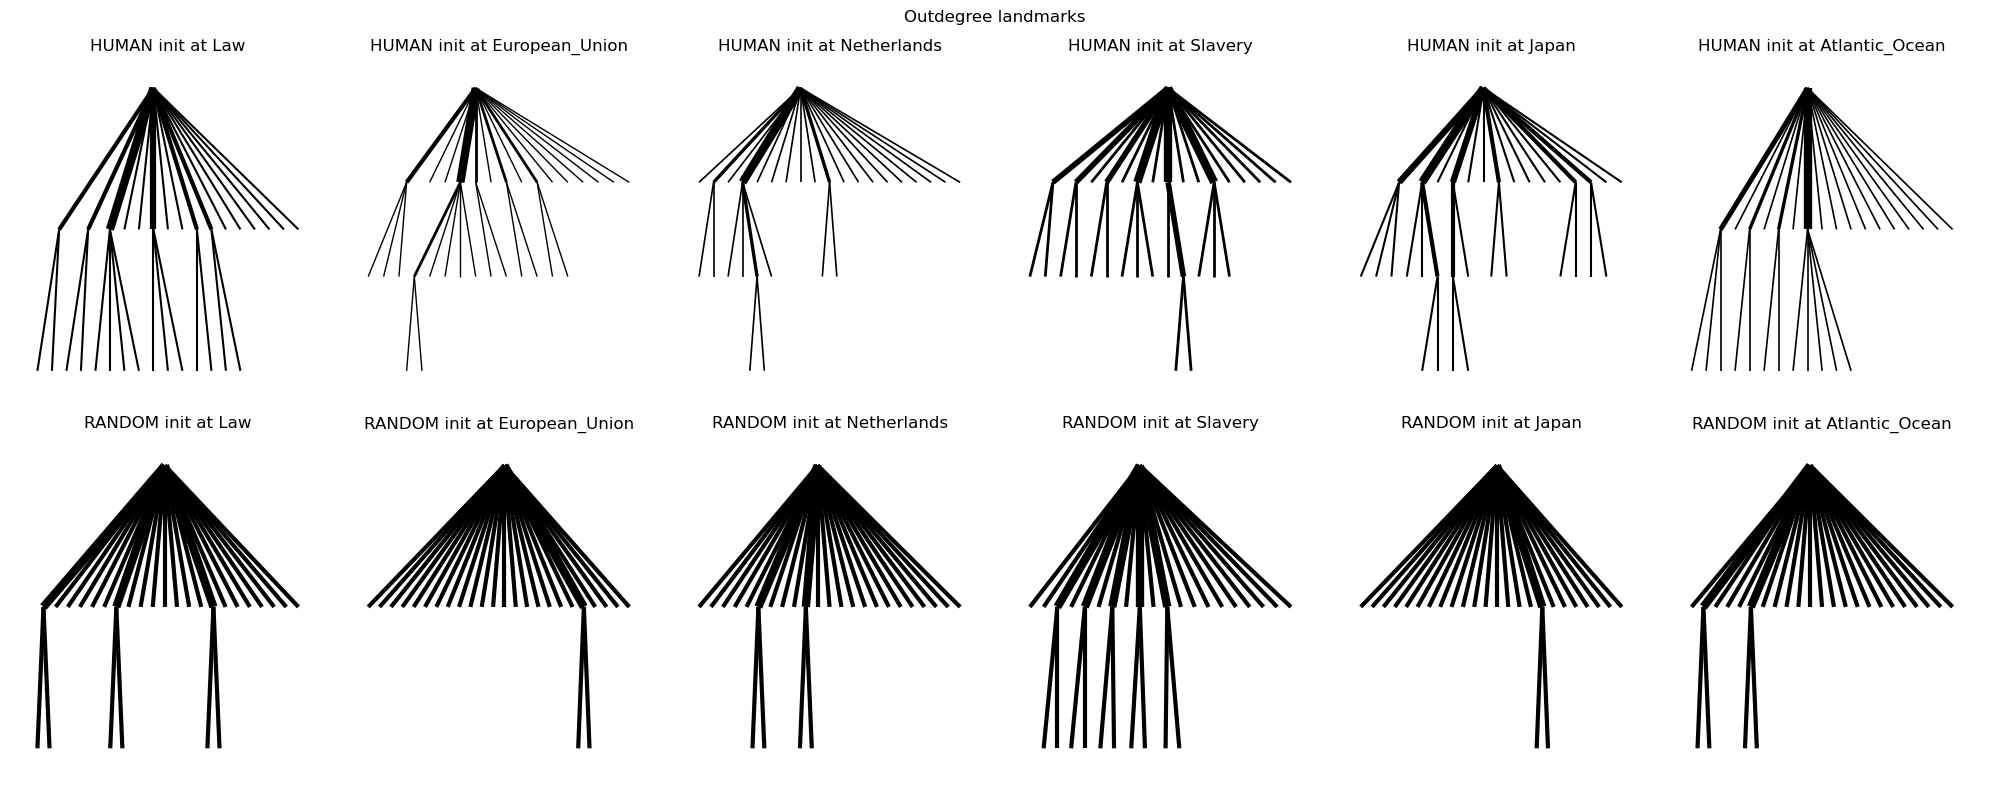

Outdegree not landmarks:


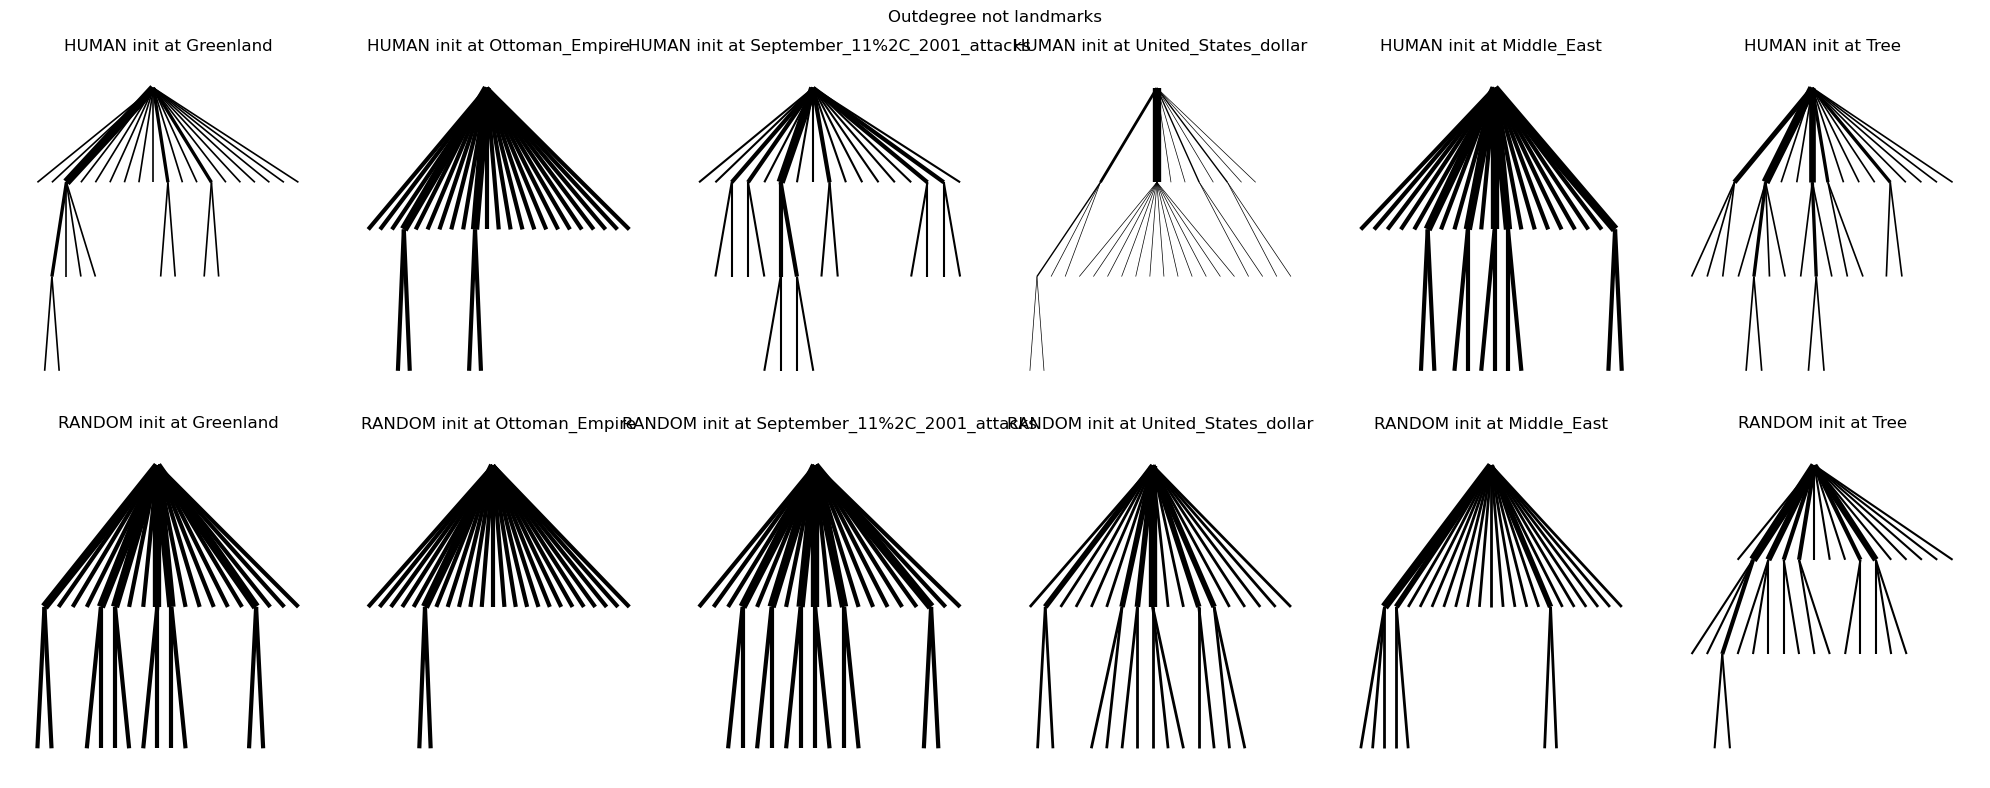

Player landmarks:


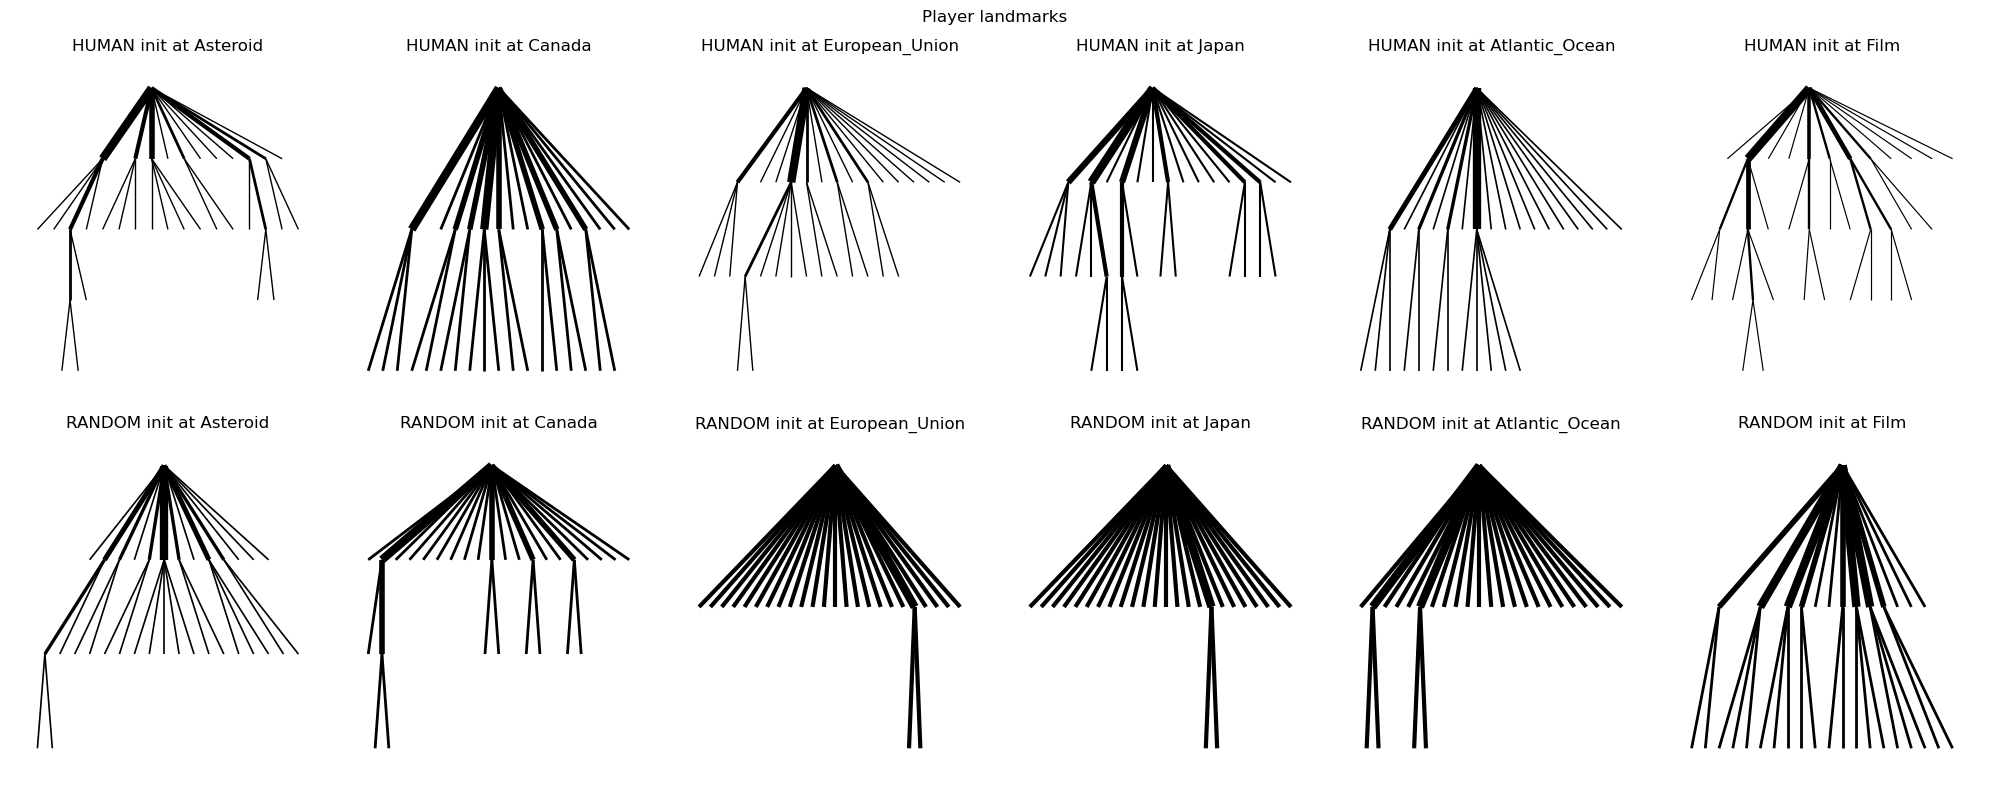

player not landmarks:


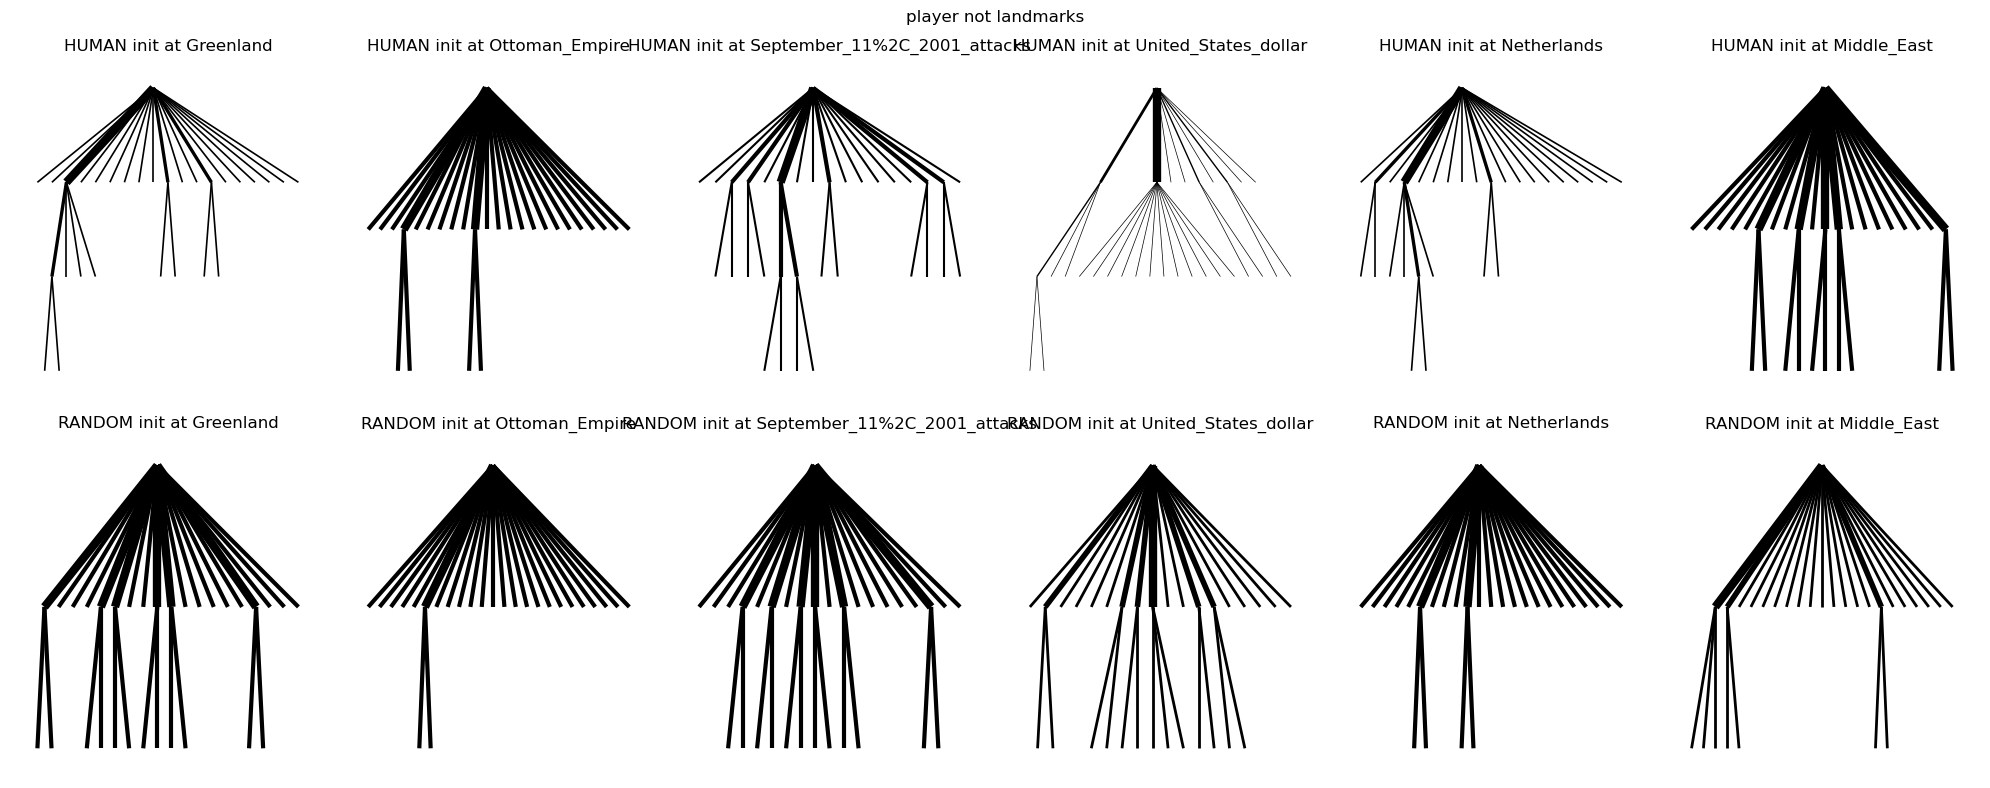

Semantic landmarks:


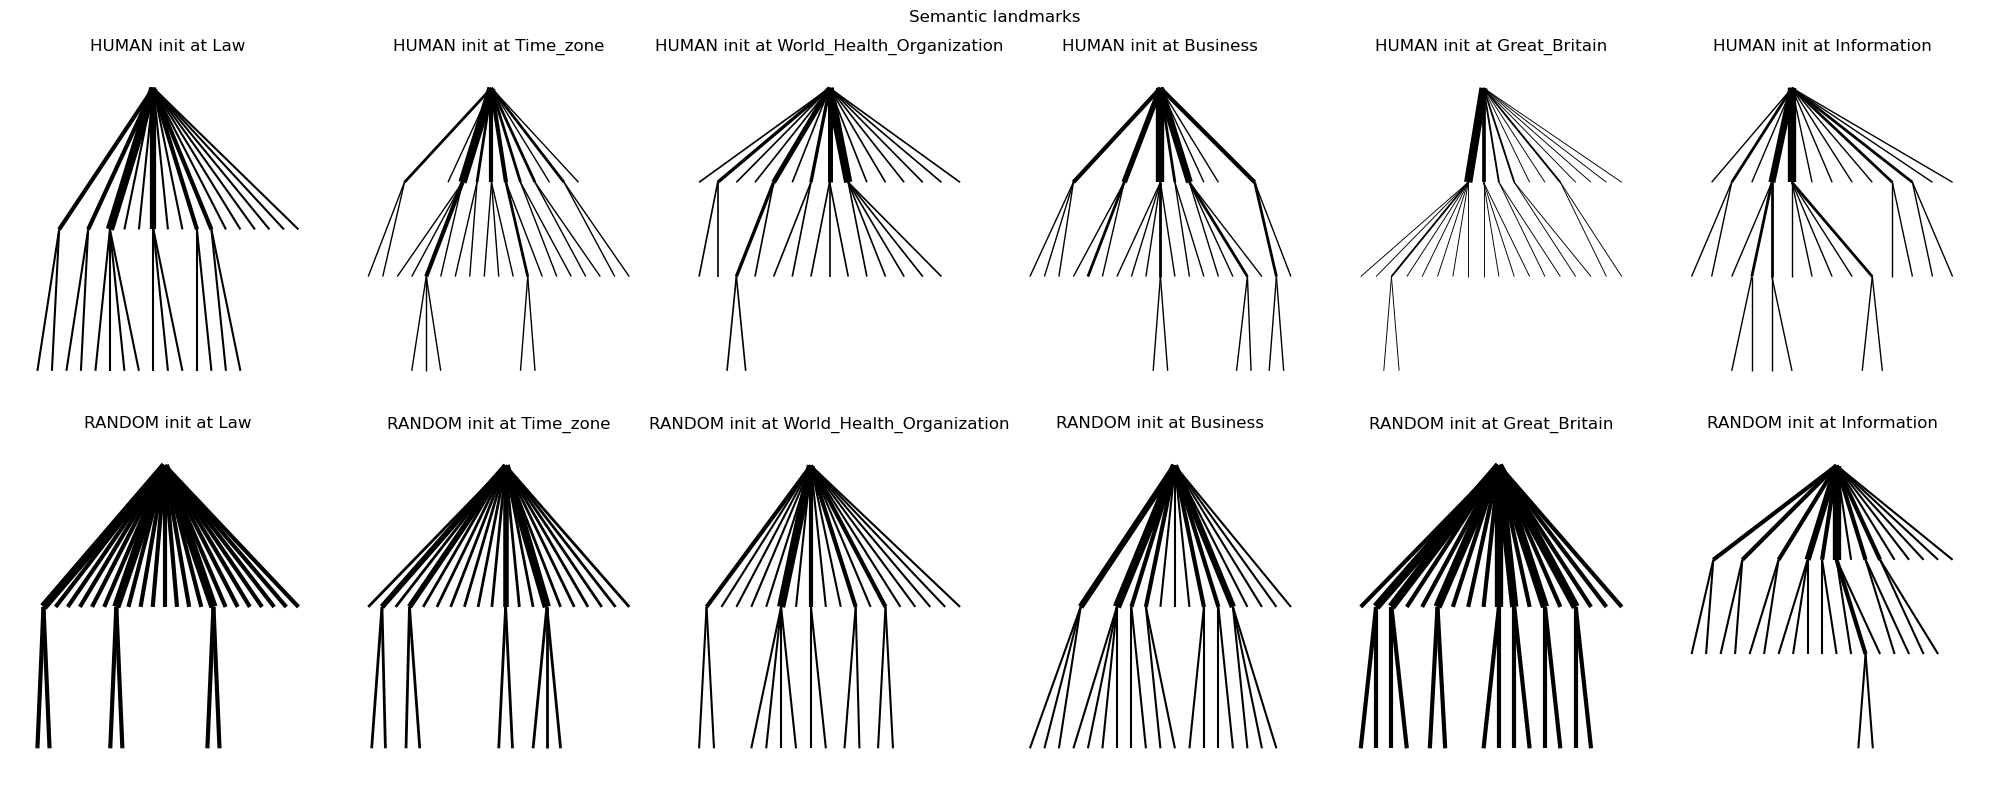

semantic not landmarks:


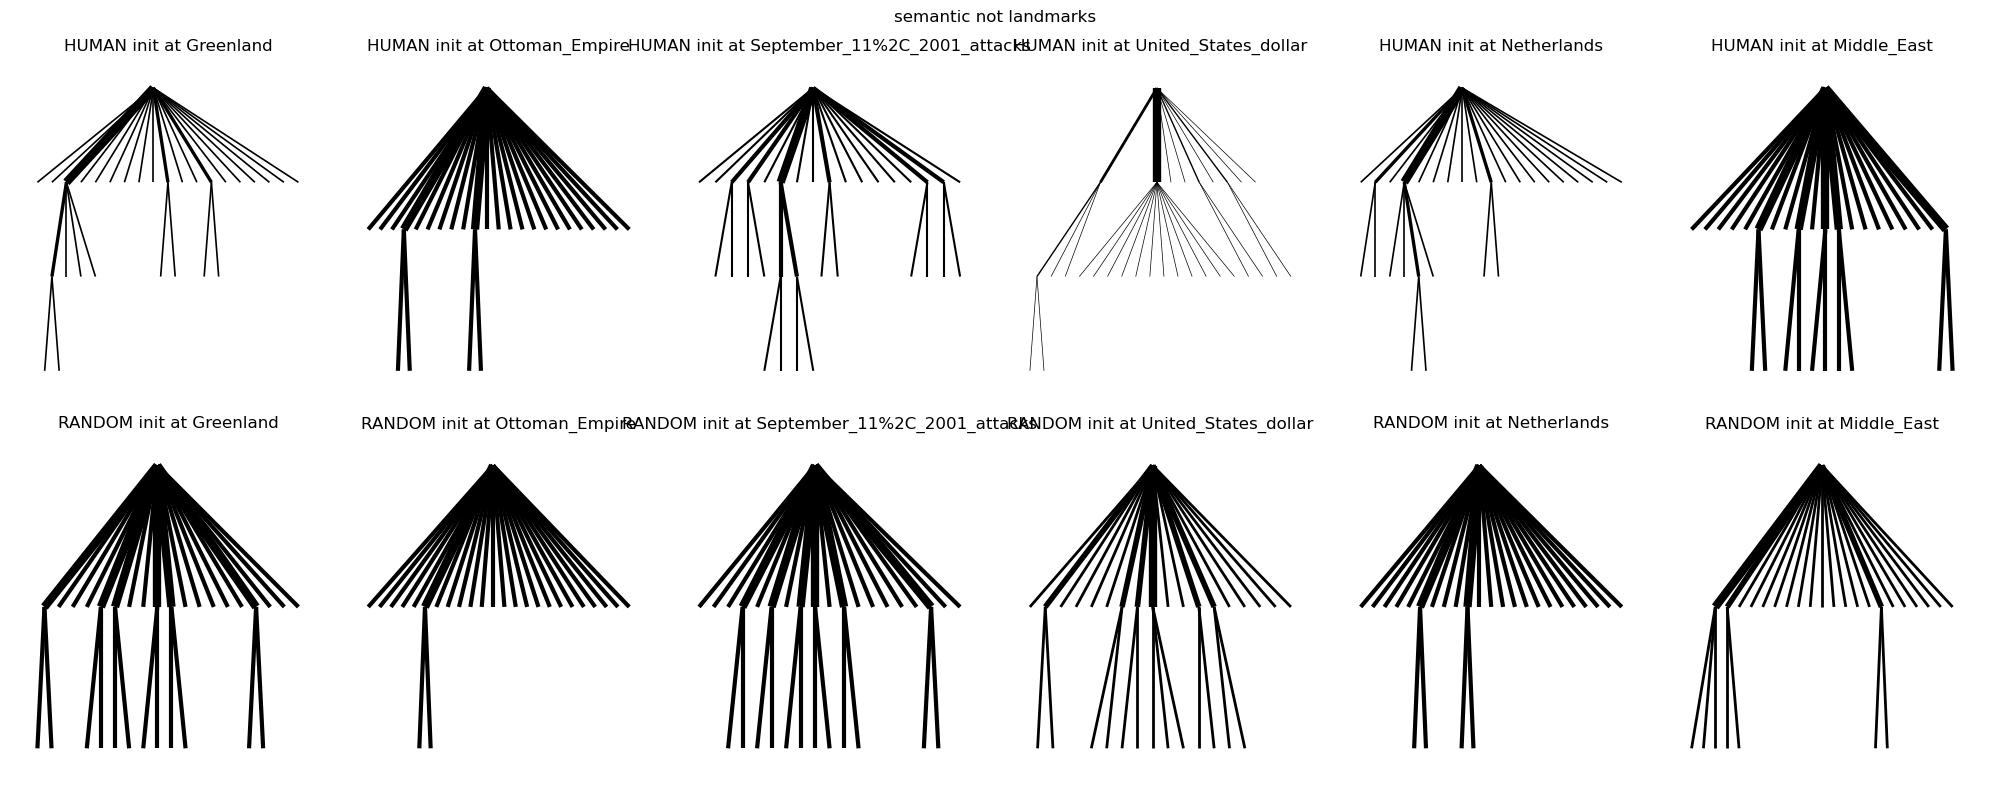

In [ ]:
print("Outdegree landmarks:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in outdegree_landmarks},
    title_str="Outdegree landmarks",
)
print("Outdegree not landmarks:")
plot_some_from_flow_tree_dict(
    {
        node: most_common_flow_tree_dict[node]
        for node in (most_common_nodes - outdegree_landmarks)
    },
    title_str="Outdegree not landmarks",
)
print("Player landmarks:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in player_landmarks},
    title_str="Player landmarks",
)
print("player not landmarks:")
plot_some_from_flow_tree_dict(
    {
        node: most_common_flow_tree_dict[node]
        for node in (most_common_nodes - player_landmarks)
    },
    title_str="player not landmarks",
)
print("Semantic landmarks:")
plot_some_from_flow_tree_dict(
    {node: most_common_flow_tree_dict[node] for node in semantic_landmarks},
    title_str="Semantic landmarks",
)
print("semantic not landmarks:")
plot_some_from_flow_tree_dict(
    {
        node: most_common_flow_tree_dict[node]
        for node in (most_common_nodes - semantic_landmarks)
    },
    title_str="semantic not landmarks",
)
